✅ Libraries loaded successfully
✅ Dataset loaded successfully
STEP 1: DATASET OVERVIEW
Shape   : (1000, 11)

Columns : ['country', 'harvest_date', 'vegetable', 'price', 'available_stock', 'daily_demand', 'freshness_age', 'shelf_life_days', 'remaining_life', 'supply_demand_gap', 'wastage_risk']

First 5 rows:
     country harvest_date    vegetable   price  available_stock  daily_demand  \
0      India   2024-03-08      Cabbage  116.93              398           215   
1      India   2024-02-12        Beans  164.67              118           462   
2      India   2024-11-07       Tomato   82.28              494            74   
3  Sri Lanka   2024-07-02        Beans  173.23              239           478   
4  Sri Lanka   2024-02-08  Cauliflower  155.07              533           225   

   freshness_age  shelf_life_days  remaining_life  supply_demand_gap  \
0             23               24               1                183   
1              7               13               6          

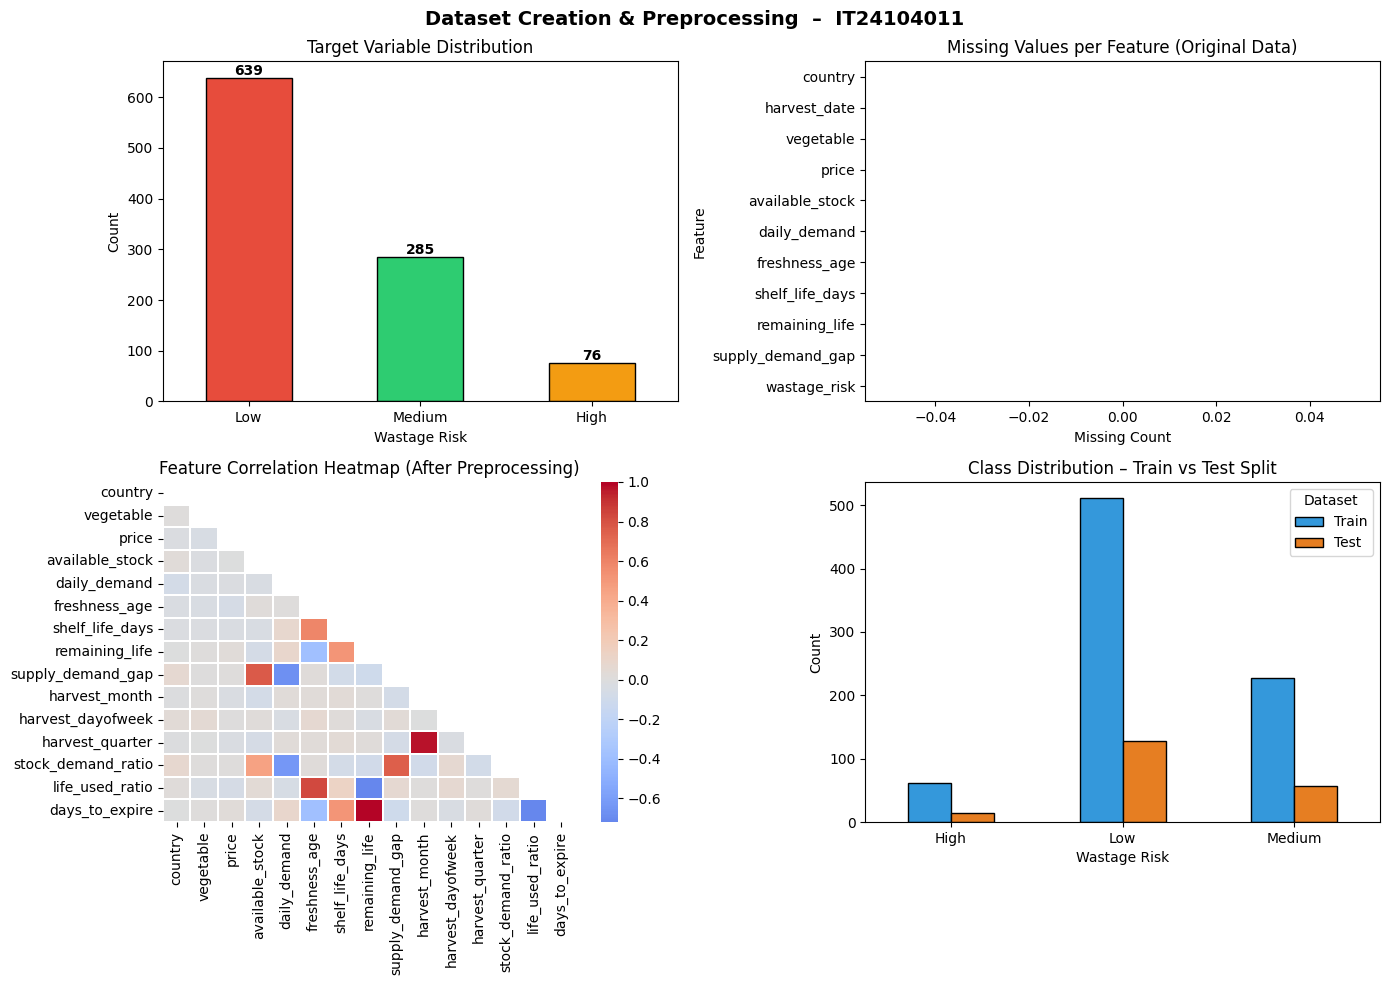

✅ Saved: preprocessing_summary.png
  PREPROCESSING COMPLETE – SUMMARY
  Total features after preprocessing : 15
  Training samples                   : 800
  Testing  samples                   : 200
  Target classes                     : ['High', 'Low', 'Medium']
  Missing values remaining           : 0
  Scaling applied                    : StandardScaler

  ✅ X_train, X_test, y_train, y_test are ready
     for the ML model training module.



In [5]:
# IT2021 AIML Project – Dataset Creation and Preprocessing
# Student : IT24104011

# Description :
# This notebook handles dataset creation, cleaning, and preprocessing
# for the vegetable demand prediction system.
#
# It includes:
#   - Handling missing values
#   - Removing redundant features (data leakage prevention)
#   - Feature engineering (date processing)
#   - Encoding categorical variables
#   - Target variable conversion
#   - Feature scaling
#   - Train-test split
#
# Output :
#   X_train, X_test, y_train, y_test,
#   df (cleaned dataset),
#   scaler (StandardScaler model)
#
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print("=" * 50)
print("✅ Libraries loaded successfully")
print("=" * 50)

# ============================================================
# CELL 2: Load Dataset
# ============================================================

DATASET_PATH = 'D:/Final project/vegetable_wastage_dataset_1000_rows (1).csv'

df      = pd.read_csv(DATASET_PATH)   # working copy
df_orig = pd.read_csv(DATASET_PATH)   # clean backup for visualizations

print("=" * 50)
print("✅ Dataset loaded successfully")
print("=" * 50)

# ============================================================
# CELL 3: STEP 1 – Dataset Overview
# ============================================================

print("=" * 50)
print("STEP 1: DATASET OVERVIEW")
print("=" * 50)

print(f"Shape   : {df.shape}")
print(f"\nColumns : {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# ============================================================
# CELL 4: STEP 2 – Data Inspection
# ============================================================

print("=" * 50)
print("STEP 2: DATA INSPECTION")
print("=" * 50)

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values per Column:")
print(df.isnull().sum())
print(f"Total missing values : {df.isnull().sum()}")
print(f"\nDuplicate Rows       : {df.duplicated().sum()}")

print("\nTarget Variable Distribution:")
print(df['wastage_risk'].value_counts())

print("\nTarget Variable (%):")
print(df['wastage_risk'].value_counts(normalize=True)
        .mul(100).round(2).astype(str) + '%')

# ============================================================
# CELL 5: STEP 3 – Handling Missing Values
# ============================================================

print("=" * 50)
print("STEP 3: HANDLING MISSING VALUES")
print("=" * 50)

# Fill numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Filled '{col}' with median.")

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  Filled '{col}' with mode.")

print(f"\n✅ Missing values after handling: {df.isnull().sum().sum()}")

# ============================================================
# CELL 6: STEP 4 – Removing Duplicates
# ============================================================

print("=" * 50)
print("STEP 4: REMOVING DUPLICATES")
print("=" * 50)

before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Removed     : {before - after} duplicate(s)")
print("✅ Done")

# ============================================================
# CELL 7: STEP 5 – Date Feature Extraction
# ============================================================

print("=" * 50)
print("STEP 5: DATE FEATURE EXTRACTION")
print("=" * 50)

df['harvest_date']      = pd.to_datetime(df['harvest_date'])
df['harvest_month']     = df['harvest_date'].dt.month
df['harvest_dayofweek'] = df['harvest_date'].dt.dayofweek
df['harvest_quarter']   = df['harvest_date'].dt.quarter
df.drop(columns=['harvest_date'], inplace=True)

print("✅ Extracted : harvest_month, harvest_dayofweek, harvest_quarter")
print("✅ Dropped   : original 'harvest_date' column")

# ============================================================
# CELL 8: STEP 6 – Encoding Categorical Variables
# ============================================================

print("=" * 50)
print("STEP 6: ENCODING CATEGORICAL VARIABLES")
print("=" * 50)

le_country   = LabelEncoder()
le_vegetable = LabelEncoder()
le_target    = LabelEncoder()

df['country']          = le_country.fit_transform(df['country'])
df['vegetable']        = le_vegetable.fit_transform(df['vegetable'])
df['wastage_risk_enc'] = le_target.fit_transform(df['wastage_risk'])

print("Country classes   :", list(le_country.classes_))
print("Vegetable classes :", list(le_vegetable.classes_))
print("Target encoding   :", dict(zip(le_target.classes_,
                                       le_target.transform(le_target.classes_))))
print("✅ Encoding complete")

# ============================================================
# CELL 9: STEP 7 – Feature Engineering
# ============================================================

print("=" * 50)
print("STEP 7: FEATURE ENGINEERING")
print("=" * 50)

df['stock_demand_ratio'] = df['available_stock'] / (df['daily_demand'] + 1)
df['life_used_ratio']    = df['freshness_age']   / (df['shelf_life_days'] + 1)
df['days_to_expire']     = df['shelf_life_days'] - df['freshness_age']

print("✅ New features created:")
print("   stock_demand_ratio – ratio of available stock to daily demand")
print("   life_used_ratio    – proportion of shelf life already consumed")
print("   days_to_expire     – remaining days before expiry")

# ============================================================
# CELL 10: STEP 8 – Feature & Target Split
# ============================================================

print("=" * 50)
print("STEP 8: FEATURE & TARGET SPLIT")
print("=" * 50)

X = df.drop(columns=['wastage_risk', 'wastage_risk_enc'])
y = df['wastage_risk_enc']

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Features used        : {list(X.columns)}")

# ============================================================
# CELL 11: STEP 9 – Train / Test Split (80% / 20%)
# ============================================================

print("=" * 50)
print("STEP 9: TRAIN / TEST SPLIT (80% / 20%)")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class proportions in both sets
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"\nClass distribution – Train:\n{y_train.value_counts()}")
print(f"\nClass distribution – Test:\n{y_test.value_counts()}")

# ============================================================
# CELL 12: STEP 10 – Feature Scaling (StandardScaler)
# ============================================================

print("=" * 50)
print("STEP 10: FEATURE SCALING (StandardScaler)")
print("=" * 50)

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print("✅ Scaling applied: mean=0, std=1 for every feature")
print("\nSample scaled training rows:")
print(X_train.head(3))

# ============================================================
# CELL 13: STEP 11 – Preprocessing Visualizations
# ============================================================

print("=" * 50)
print("STEP 11: PREPROCESSING VISUALIZATIONS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset Creation & Preprocessing  –  IT24104011",
             fontsize=14, fontweight='bold')

# ── Plot 1: Target class distribution ───────────────────────
ax     = axes[0, 0]
colors = ['#e74c3c', '#2ecc71', '#f39c12']
df_orig['wastage_risk'].value_counts().plot(
    kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title("Target Variable Distribution")
ax.set_xlabel("Wastage Risk")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

# ── Plot 2: Missing values per feature ──────────────────────
ax           = axes[0, 1]
missing_data = df_orig.isnull().sum().reset_index()
missing_data.columns = ['Feature', 'Missing Count']
sns.barplot(data=missing_data, x='Missing Count',
            y='Feature', ax=ax, color='steelblue')
ax.set_title("Missing Values per Feature (Original Data)")
ax.set_xlabel("Missing Count")

# ── Plot 3: Feature correlation heatmap ─────────────────────
ax   = axes[1, 0]
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, cmap='coolwarm', annot=False,
            linewidths=0.3, mask=mask, center=0)
ax.set_title("Feature Correlation Heatmap (After Preprocessing)")

# ── Plot 4: Class balance Train vs Test ─────────────────────
ax       = axes[1, 1]
split_df = pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Test' : y_test.value_counts().sort_index()
})
split_df.index = [le_target.classes_[i] for i in split_df.index]
split_df.plot(kind='bar', ax=ax,
              color=['#3498db', '#e67e22'], edgecolor='black')
ax.set_title("Class Distribution – Train vs Test Split")
ax.set_xlabel("Wastage Risk")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Dataset')

plt.tight_layout()
plt.savefig("preprocessing_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: preprocessing_summary.png")

# ============================================================
# CELL 14: PREPROCESSING COMPLETE – SUMMARY
# ============================================================

print("=" * 55)
print("  PREPROCESSING COMPLETE – SUMMARY")
print("=" * 55)
print(f"  Total features after preprocessing : {X_train.shape[1]}")
print(f"  Training samples                   : {X_train.shape[0]}")
print(f"  Testing  samples                   : {X_test.shape[0]}")
print(f"  Target classes                     : {list(le_target.classes_)}")
print(f"  Missing values remaining           : 0")
print(f"  Scaling applied                    : StandardScaler")
print("\n  ✅ X_train, X_test, y_train, y_test are ready")
print("     for the ML model training module.\n")

EDA & FEATURE ENGINEERING  –  IT24101661
df shape coming from preprocessing : (1000, 17)
X_train shape                      : (800, 15)
Target classes                     : ['High', 'Low', 'Medium']

EDA A1: DAILY DEMAND ANALYSIS


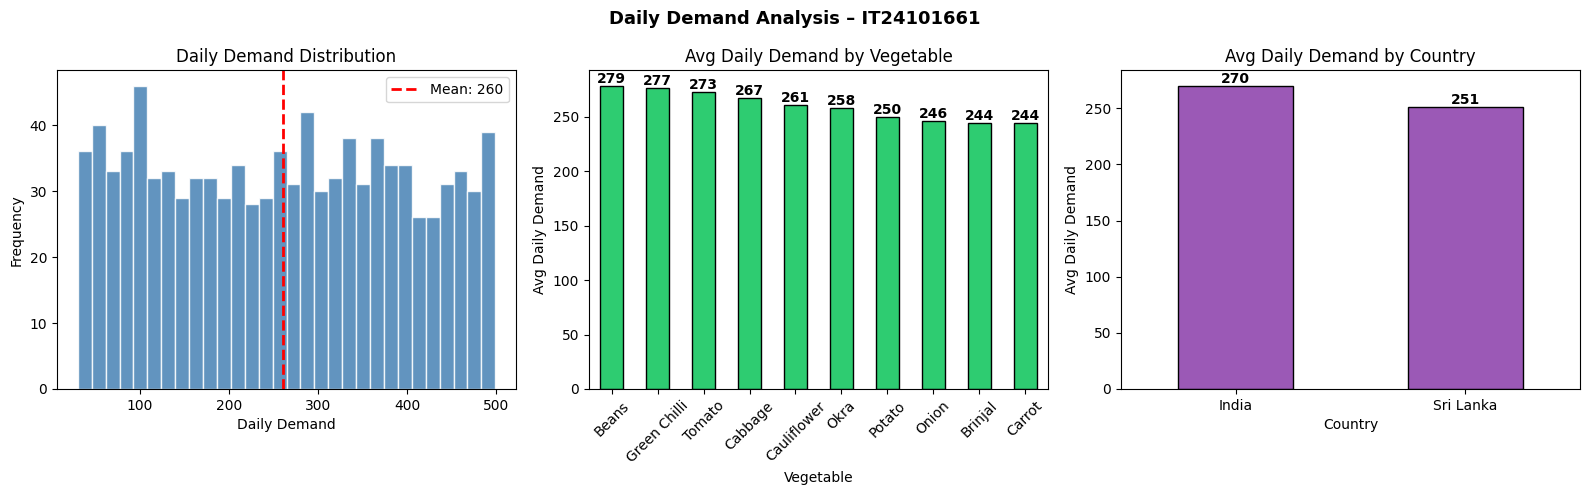


EDA A2: MONTHLY & QUARTERLY DEMAND TRENDS


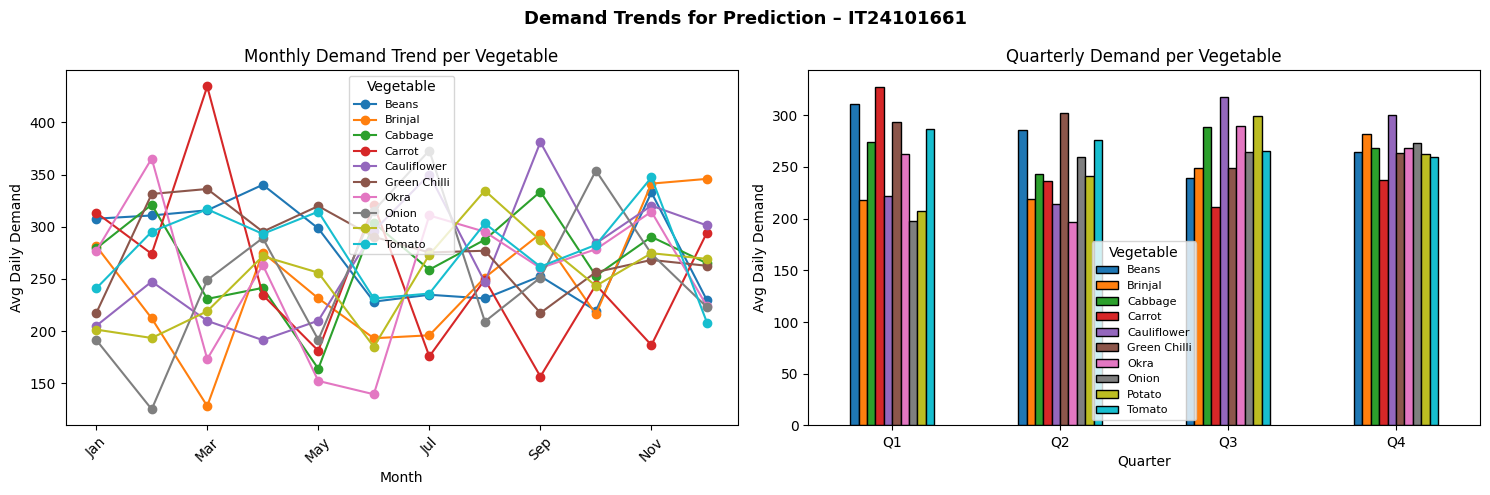

Insight: Seasonal demand patterns guide the 14-day demand prediction model.

EDA A3: STOCK vs DEMAND GAP ANALYSIS


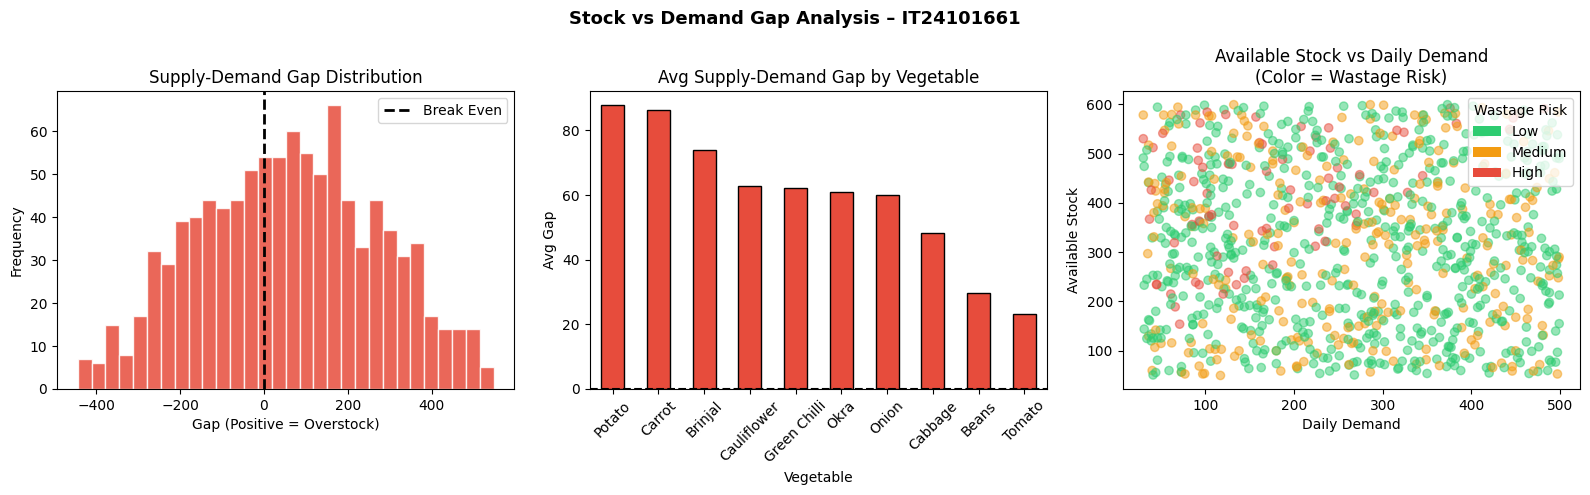

Insight: Positive gap = overstock = High wastage risk.

EDA A4: SHELF LIFE & FRESHNESS ANALYSIS


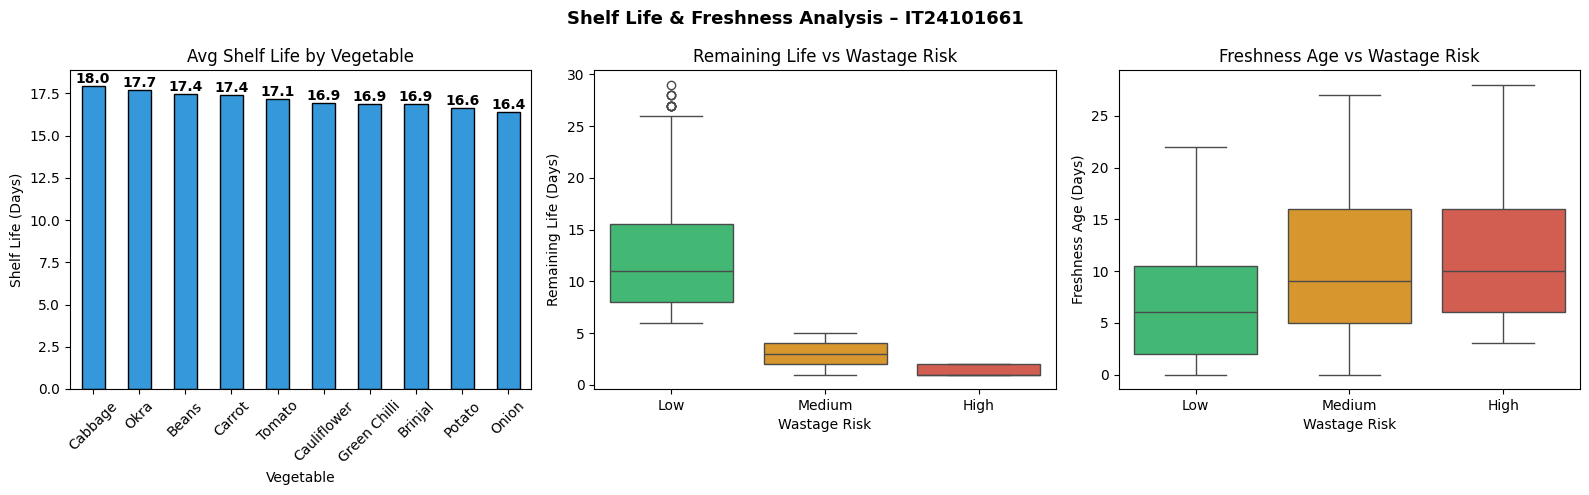

Insight: Low remaining_life + high freshness_age → High wastage risk.

EDA A5: PREDICTED 14-DAY DEMAND → WASTAGE RISK


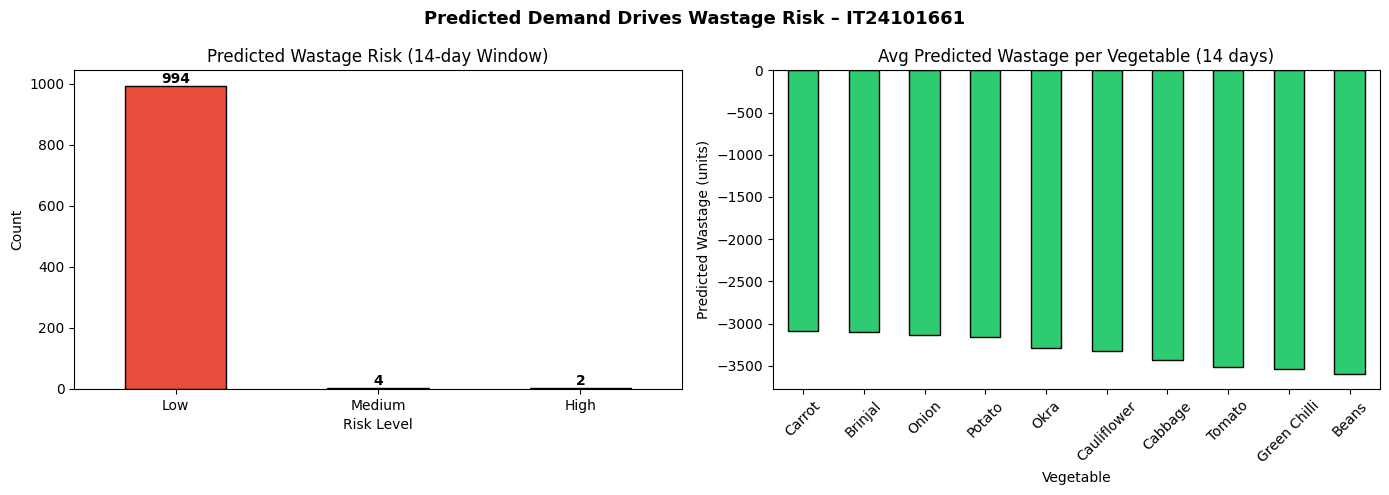

Insight: Red bars = overstock after 14-day window = High wastage risk.

EDA A6: CORRELATION HEATMAP


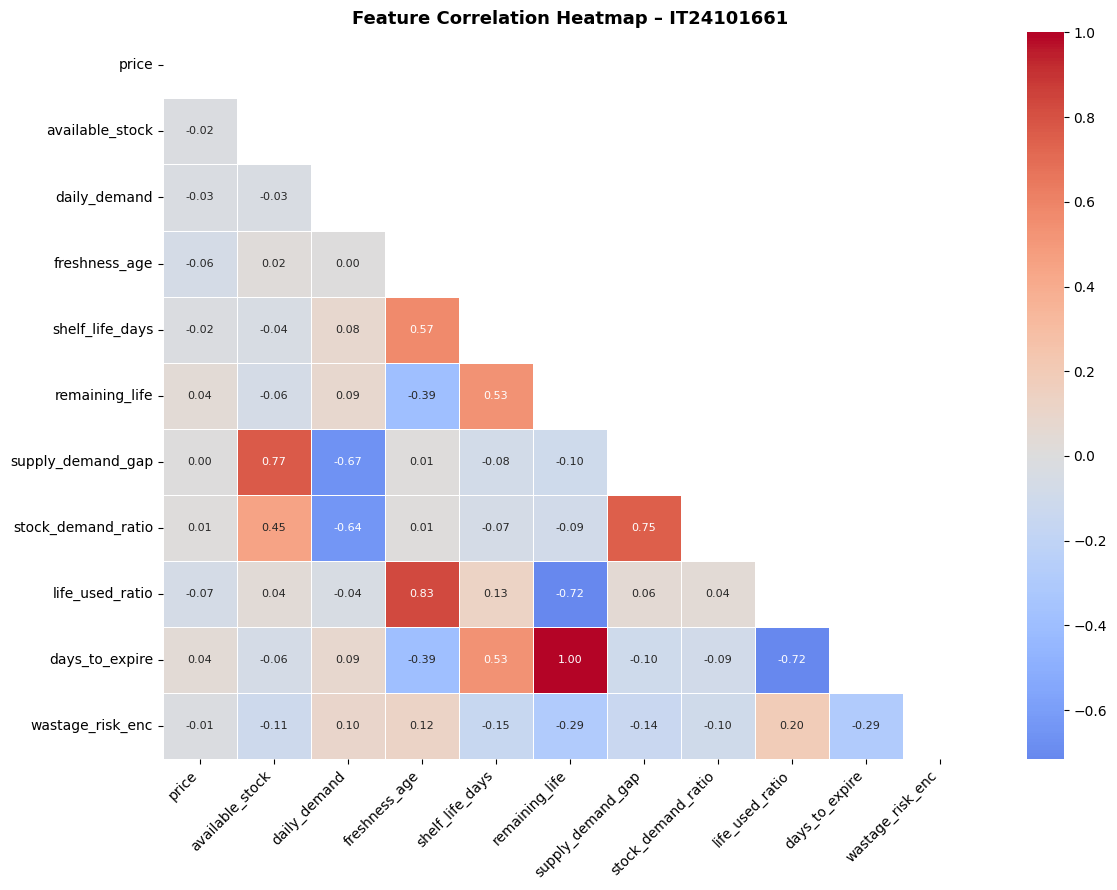


Top correlations with wastage_risk_enc:
days_to_expire        0.288586
remaining_life        0.288586
life_used_ratio       0.195639
shelf_life_days       0.149755
supply_demand_gap     0.143182
freshness_age         0.116430
available_stock       0.107038
daily_demand          0.098619
stock_demand_ratio    0.095639
price                 0.013399

FEATURE ENGINEERING  –  IT24101661
8 new features added (IT24101661):
  1. predicted_14day_demand       – Total demand over the next 2 weeks
  2. stock_after_14days           – Stock remaining after 14-day demand window
  3. shortage_in_14days           – Binary – will stock run out within 14 days?
  4. potential_wastage_units      – Units likely wasted if stock is not consumed
  5. expires_before_14days        – Binary – does item expire within 14 days?
  6. freshness_pct_remaining      – % of shelf life still remaining
  7. price_demand_ratio           – Unit price relative to daily demand
  8. overstock_flag               – Binary – supp

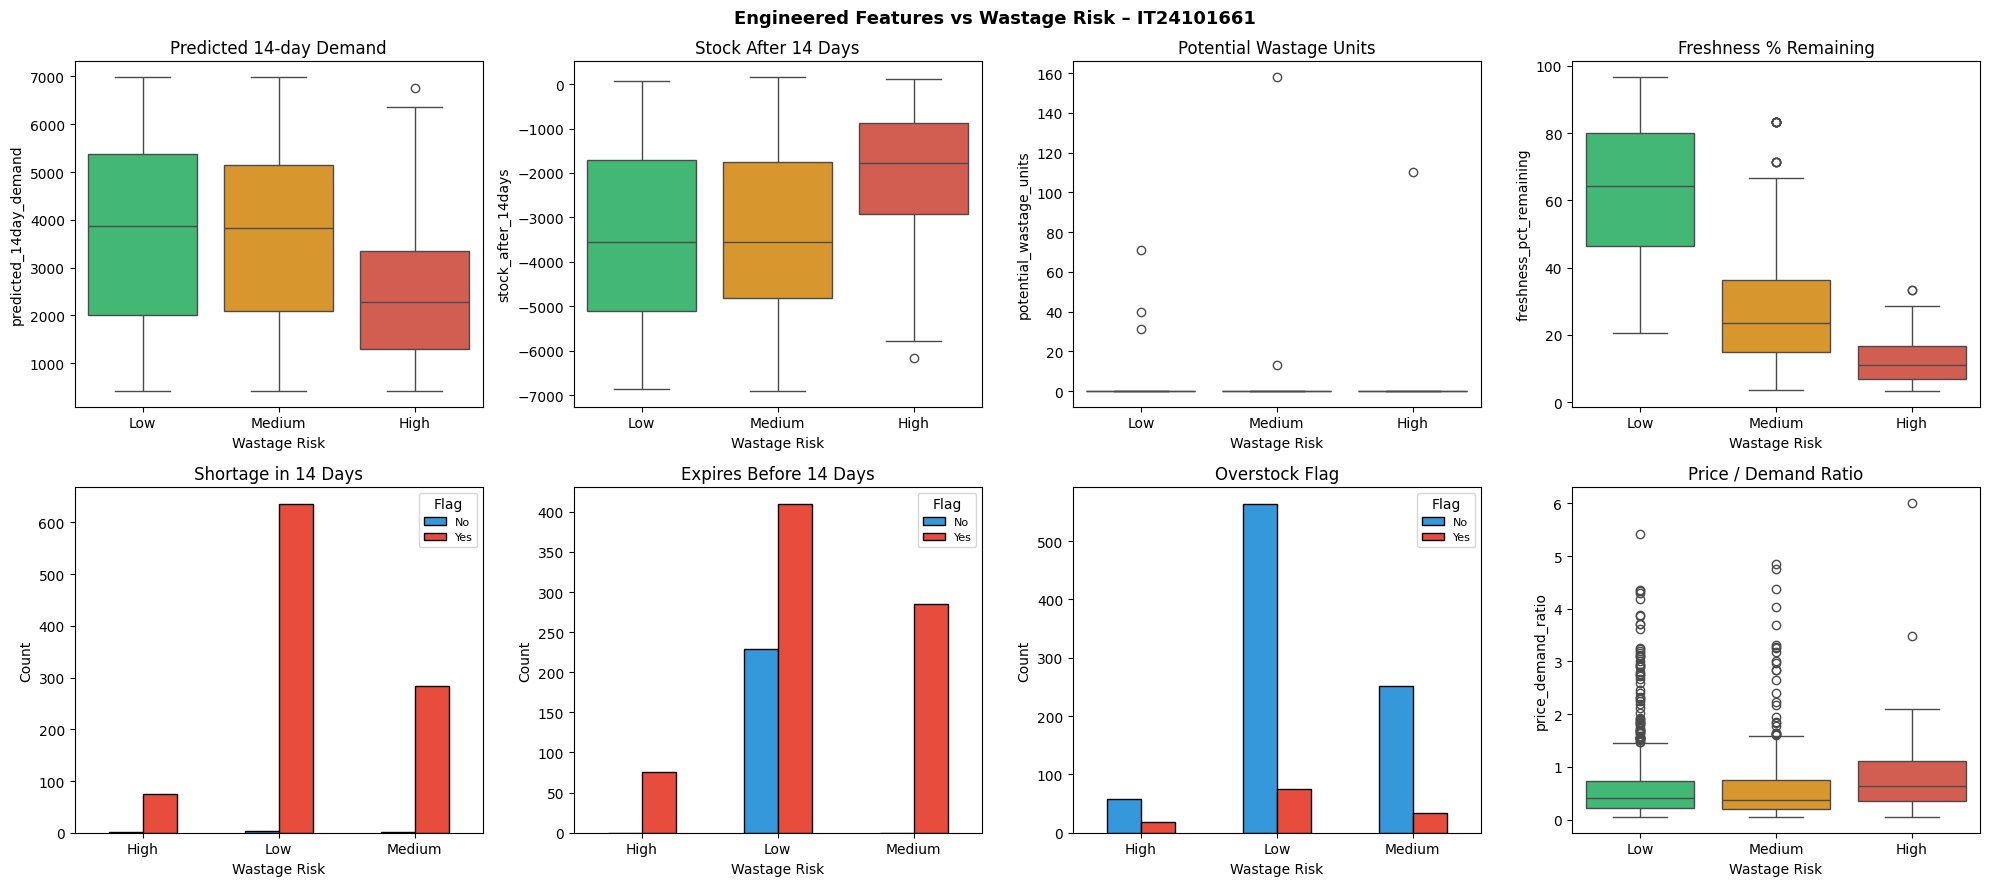


FINAL ENGINEERED DATASET SUMMARY
Total Rows    : 1000
Total Columns : 24

All columns:
   1. country
   2. vegetable
   3. price
   4. available_stock
   5. daily_demand
   6. freshness_age
   7. shelf_life_days
   8. remaining_life
   9. supply_demand_gap
  10. harvest_month
  11. harvest_dayofweek
  12. harvest_quarter
  13. wastage_risk_enc
  14. stock_demand_ratio
  15. life_used_ratio
  16. days_to_expire
  17. predicted_14day_demand
  18. stock_after_14days
  19. shortage_in_14days
  20. potential_wastage_units
  21. expires_before_14days
  22. freshness_pct_remaining
  23. price_demand_ratio
  24. overstock_flag

First 5 rows:
   country  vegetable   price  available_stock  daily_demand  freshness_age  \
0        0          2  116.93              398           215             23   
1        0          0  164.67              118           462              7   
2        0          9   82.28              494            74              3   
3        1          0  173.23            

In [6]:
# ============================================================
# IT2021 AIML Project – EDA & Feature Engineering
# Student : IT24101661
# Feature : EDA + Feature Engineering
# Depends on : IT24104011 preprocessing output
#              (X_train, X_test, y_train, y_test, df, df_orig,
#               le_country, le_vegetable, le_target, scaler)
# ============================================================
# HOW TO USE:
#   Run IT24104011's preprocessing notebook FIRST.
#   Then paste / run this notebook in the SAME Colab session
#   so all variables are already in memory.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── safety check ────────────────────────────────────────────
required = ['df', 'df_orig', 'X_train', 'X_test',
            'y_train', 'y_test', 'le_target']
for v in required:
    if v not in dir():
        raise NameError(
            f"Variable '{v}' not found. "
            "Please run IT24104011's preprocessing notebook first."
        )

print("=" * 60)
print("EDA & FEATURE ENGINEERING  –  IT24101661")
print("=" * 60)
print(f"df shape coming from preprocessing : {df.shape}")
print(f"X_train shape                      : {X_train.shape}")
print(f"Target classes                     : {list(le_target.classes_)}")

# ============================================================
# SECTION A – EXPLORATORY DATA ANALYSIS (EDA)
# We use df_orig (raw, un-encoded CSV) for readable plots,
# and df (encoded, engineered) where numeric features are needed.
# ============================================================

# ─── A1. Daily Demand Analysis ──────────────────────────────
print("\n" + "=" * 60)
print("EDA A1: DAILY DEMAND ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Daily Demand Analysis – IT24101661",
             fontsize=13, fontweight='bold')

# A1-1  Overall distribution
axes[0].hist(df_orig['daily_demand'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_orig['daily_demand'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df_orig['daily_demand'].mean():.0f}")
axes[0].set_title("Daily Demand Distribution")
axes[0].set_xlabel("Daily Demand")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# A1-2  By vegetable
avg_veg = (df_orig.groupby('vegetable')['daily_demand']
           .mean().sort_values(ascending=False))
avg_veg.plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title("Avg Daily Demand by Vegetable")
axes[1].set_xlabel("Vegetable")
axes[1].set_ylabel("Avg Daily Demand")
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.0f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# A1-3  By country
avg_country = df_orig.groupby('country')['daily_demand'].mean()
avg_country.plot(kind='bar', ax=axes[2], color='#9b59b6', edgecolor='black')
axes[2].set_title("Avg Daily Demand by Country")
axes[2].set_xlabel("Country")
axes[2].set_ylabel("Avg Daily Demand")
axes[2].tick_params(axis='x', rotation=0)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.0f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("eda_A1_daily_demand.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── A2. Monthly & Quarterly Demand Trends ──────────────────
print("\n" + "=" * 60)
print("EDA A2: MONTHLY & QUARTERLY DEMAND TRENDS")
print("=" * 60)

trend_df = df_orig.copy()
trend_df['harvest_date'] = pd.to_datetime(trend_df['harvest_date'])
trend_df['month']   = trend_df['harvest_date'].dt.month
trend_df['quarter'] = trend_df['harvest_date'].dt.quarter

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Demand Trends for Prediction – IT24101661",
             fontsize=13, fontweight='bold')

# Monthly per vegetable
monthly_veg = (trend_df.groupby(['month', 'vegetable'])['daily_demand']
               .mean().unstack())
monthly_veg.index = [month_names[m] for m in monthly_veg.index]
monthly_veg.plot(kind='line', ax=axes[0], marker='o')
axes[0].set_title("Monthly Demand Trend per Vegetable")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Daily Demand")
axes[0].legend(title='Vegetable', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# Quarterly per vegetable
q_avg = (trend_df.groupby(['quarter', 'vegetable'])['daily_demand']
         .mean().unstack())
q_avg.index = [f"Q{q}" for q in q_avg.index]
q_avg.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title("Quarterly Demand per Vegetable")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Avg Daily Demand")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Vegetable', fontsize=8)

plt.tight_layout()
plt.savefig("eda_A2_demand_trends.png", dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Seasonal demand patterns guide the 14-day demand prediction model.")

# ─── A3. Stock vs Demand Gap Analysis ───────────────────────
print("\n" + "=" * 60)
print("EDA A3: STOCK vs DEMAND GAP ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Stock vs Demand Gap Analysis – IT24101661",
             fontsize=13, fontweight='bold')

# Distribution of gap
axes[0].hist(df_orig['supply_demand_gap'], bins=30,
             color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--',
                linewidth=2, label='Break Even')
axes[0].set_title("Supply-Demand Gap Distribution")
axes[0].set_xlabel("Gap (Positive = Overstock)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Gap by vegetable
gap_veg = (df_orig.groupby('vegetable')['supply_demand_gap']
           .mean().sort_values(ascending=False))
gap_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in gap_veg]
gap_veg.plot(kind='bar', ax=axes[1], color=gap_colors, edgecolor='black')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("Avg Supply-Demand Gap by Vegetable")
axes[1].set_xlabel("Vegetable")
axes[1].set_ylabel("Avg Gap")
axes[1].tick_params(axis='x', rotation=45)

# Scatter: stock vs demand coloured by wastage risk
risk_color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
scatter_colors = df_orig['wastage_risk'].map(risk_color_map)
axes[2].scatter(df_orig['daily_demand'], df_orig['available_stock'],
                c=scatter_colors, alpha=0.5)
axes[2].set_title("Available Stock vs Daily Demand\n(Color = Wastage Risk)")
axes[2].set_xlabel("Daily Demand")
axes[2].set_ylabel("Available Stock")
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(facecolor=c, label=l)
                         for l, c in risk_color_map.items()],
               title='Wastage Risk')

plt.tight_layout()
plt.savefig("eda_A3_stock_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Positive gap = overstock = High wastage risk.")

# ─── A4. Shelf Life & Freshness Analysis ────────────────────
print("\n" + "=" * 60)
print("EDA A4: SHELF LIFE & FRESHNESS ANALYSIS")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Shelf Life & Freshness Analysis – IT24101661",
             fontsize=13, fontweight='bold')

order   = ['Low', 'Medium', 'High']
palette = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

# Avg shelf life by vegetable
shelf_veg = (df_orig.groupby('vegetable')['shelf_life_days']
             .mean().sort_values(ascending=False))
shelf_veg.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title("Avg Shelf Life by Vegetable")
axes[0].set_xlabel("Vegetable")
axes[0].set_ylabel("Shelf Life (Days)")
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Remaining life vs wastage risk
sns.boxplot(data=df_orig, x='wastage_risk', y='remaining_life',
            order=order, palette=palette, ax=axes[1])
axes[1].set_title("Remaining Life vs Wastage Risk")
axes[1].set_xlabel("Wastage Risk")
axes[1].set_ylabel("Remaining Life (Days)")

# Freshness age vs wastage risk
sns.boxplot(data=df_orig, x='wastage_risk', y='freshness_age',
            order=order, palette=palette, ax=axes[2])
axes[2].set_title("Freshness Age vs Wastage Risk")
axes[2].set_xlabel("Wastage Risk")
axes[2].set_ylabel("Freshness Age (Days)")

plt.tight_layout()
plt.savefig("eda_A4_shelf_freshness.png", dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Low remaining_life + high freshness_age → High wastage risk.")

# ─── A5. Predicted 14-Day Demand vs Wastage Risk ────────────
print("\n" + "=" * 60)
print("EDA A5: PREDICTED 14-DAY DEMAND → WASTAGE RISK")
print("=" * 60)

# Work on a clean copy – never mutate df_orig
eda5 = df_orig.copy()
eda5['predicted_14day_demand'] = eda5['daily_demand'] * 14
eda5['predicted_wastage']      = eda5['available_stock'] - eda5['predicted_14day_demand']

def classify_predicted_risk(row):
    if row['predicted_wastage'] > 100:
        return 'High'
    elif row['predicted_wastage'] > 0:
        return 'Medium'
    else:
        return 'Low'

eda5['predicted_risk'] = eda5.apply(classify_predicted_risk, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Predicted Demand Drives Wastage Risk – IT24101661",
             fontsize=13, fontweight='bold')

risk_counts = eda5['predicted_risk'].value_counts()
risk_counts.plot(kind='bar', ax=axes[0],
                 color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[0].set_title("Predicted Wastage Risk (14-day Window)")
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

wastage_veg = (eda5.groupby('vegetable')['predicted_wastage']
               .mean().sort_values(ascending=False))
w_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in wastage_veg]
wastage_veg.plot(kind='bar', ax=axes[1], color=w_colors, edgecolor='black')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title("Avg Predicted Wastage per Vegetable (14 days)")
axes[1].set_xlabel("Vegetable")
axes[1].set_ylabel("Predicted Wastage (units)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("eda_A5_predicted_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Red bars = overstock after 14-day window = High wastage risk.")

# ─── A6. Correlation Heatmap ────────────────────────────────
print("\n" + "=" * 60)
print("EDA A6: CORRELATION HEATMAP")
print("=" * 60)

# Use the friend's engineered numeric df (already has days_to_expire etc.)
corr_cols = ['price', 'available_stock', 'daily_demand', 'freshness_age',
             'shelf_life_days', 'remaining_life', 'supply_demand_gap',
             'stock_demand_ratio', 'life_used_ratio', 'days_to_expire',
             'wastage_risk_enc']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title("Feature Correlation Heatmap – IT24101661",
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("eda_A6_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with wastage_risk_enc:")
print(corr_matrix['wastage_risk_enc']
      .drop('wastage_risk_enc')
      .abs()
      .sort_values(ascending=False)
      .to_string())

# ============================================================
# SECTION B – MY FEATURE ENGINEERING  (IT24101661)
# Built on top of IT24104011's 3 features:
#   stock_demand_ratio, life_used_ratio, days_to_expire
# ============================================================
print("\n" + "=" * 60)
print("FEATURE ENGINEERING  –  IT24101661")
print("=" * 60)

# ── B1. 14-day demand prediction features ───────────────────
# Feature 1 : Total demand over next 2 weeks
df['predicted_14day_demand'] = df['daily_demand'] * 14

# Feature 2 : Stock left after 14-day demand is met
df['stock_after_14days'] = df['available_stock'] - df['predicted_14day_demand']

# Feature 3 : Will stock run out? (binary shortage flag)
df['shortage_in_14days'] = (df['stock_after_14days'] < 0).astype(int)

# Feature 4 : Units likely wasted if demand doesn't clear stock
df['potential_wastage_units'] = df['stock_after_14days'].clip(lower=0)

# ── B2. Freshness / expiry urgency features ─────────────────
# Feature 5 : Will it expire within the 14-day window?
df['expires_before_14days'] = (df['days_to_expire'] < 14).astype(int)

# Feature 6 : What % of shelf life is still remaining?
df['freshness_pct_remaining'] = (
    df['days_to_expire'] / (df['shelf_life_days'] + 1)
) * 100

# ── B3. Price / value pressure features ─────────────────────
# Feature 7 : How much does one unit cost relative to daily demand?
df['price_demand_ratio'] = df['price'] / (df['daily_demand'] + 1)

# Feature 8 : Is stock massively above demand? (binary overstock flag)
df['overstock_flag'] = (
    df['supply_demand_gap'] > df['daily_demand'] * 3
).astype(int)

print("8 new features added (IT24101661):")
feature_descriptions = {
    'predicted_14day_demand' : 'Total demand over the next 2 weeks',
    'stock_after_14days'     : 'Stock remaining after 14-day demand window',
    'shortage_in_14days'     : 'Binary – will stock run out within 14 days?',
    'potential_wastage_units': 'Units likely wasted if stock is not consumed',
    'expires_before_14days'  : 'Binary – does item expire within 14 days?',
    'freshness_pct_remaining': '% of shelf life still remaining',
    'price_demand_ratio'     : 'Unit price relative to daily demand',
    'overstock_flag'         : 'Binary – supply gap > 3× daily demand',
}
for i, (feat, desc) in enumerate(feature_descriptions.items(), 1):
    print(f"  {i}. {feat:<28} – {desc}")

print(f"\nDataset shape after feature engineering : {df.shape}")

# ─── B4. Visualise the new features ─────────────────────────
print("\n" + "=" * 60)
print("FEATURE ENGINEERING VISUALISATIONS")
print("=" * 60)

target_labels = df['wastage_risk_enc'].map(
    dict(enumerate(le_target.classes_))
)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Engineered Features vs Wastage Risk – IT24101661",
             fontsize=13, fontweight='bold')

numeric_feats = [
    ('predicted_14day_demand',  'Predicted 14-day Demand'),
    ('stock_after_14days',      'Stock After 14 Days'),
    ('potential_wastage_units', 'Potential Wastage Units'),
    ('freshness_pct_remaining', 'Freshness % Remaining'),
    ('price_demand_ratio',      'Price / Demand Ratio'),
]
binary_feats = [
    ('shortage_in_14days',   'Shortage in 14 Days'),
    ('expires_before_14days','Expires Before 14 Days'),
    ('overstock_flag',       'Overstock Flag'),
]

palette = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
all_axes = axes.flatten()
plot_idx = 0

for feat, title in numeric_feats[:4]:
    sns.boxplot(x=target_labels, y=df[feat],
                order=['Low', 'Medium', 'High'],
                palette=palette, ax=all_axes[plot_idx])
    all_axes[plot_idx].set_title(title)
    all_axes[plot_idx].set_xlabel("Wastage Risk")
    all_axes[plot_idx].set_ylabel(feat)
    plot_idx += 1

for feat, title in binary_feats:
    cross = pd.crosstab(target_labels, df[feat])
    cross.columns = ['No', 'Yes']
    cross.plot(kind='bar', ax=all_axes[plot_idx],
               color=['#3498db', '#e74c3c'], edgecolor='black')
    all_axes[plot_idx].set_title(title)
    all_axes[plot_idx].set_xlabel("Wastage Risk")
    all_axes[plot_idx].set_ylabel("Count")
    all_axes[plot_idx].tick_params(axis='x', rotation=0)
    all_axes[plot_idx].legend(title='Flag', fontsize=8)
    plot_idx += 1

# Last panel – price_demand_ratio box
feat, title = numeric_feats[4]
sns.boxplot(x=target_labels, y=df[feat],
            order=['Low', 'Medium', 'High'],
            palette=palette, ax=all_axes[plot_idx])
all_axes[plot_idx].set_title(title)
all_axes[plot_idx].set_xlabel("Wastage Risk")
all_axes[plot_idx].set_ylabel(feat)

plt.tight_layout()
plt.savefig("fe_B4_feature_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SECTION C – SAVE FINAL ENGINEERED DATASET
# ============================================================
print("\n" + "=" * 60)
print("FINAL ENGINEERED DATASET SUMMARY")
print("=" * 60)

# Drop helper / target string columns before saving
cols_to_drop = ['wastage_risk']   # encoded version kept as wastage_risk_enc
final_df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Total Rows    : {final_df.shape[0]}")
print(f"Total Columns : {final_df.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(final_df.columns, 1):
    print(f"  {i:2}. {col}")

print("\nFirst 5 rows:")
print(final_df.head())

output_filename = 'IT24101661_engineered_dataset.csv'
final_df.to_csv(output_filename, index=False)
print(f"\nSaved as: {output_filename}  |  Shape: {final_df.shape}")

# Download (Colab only – skipped silently when running locally)
try:
    from google.colab import files
    files.download(output_filename)
except ImportError:
    print("(Not in Colab – file saved locally.)")

# ============================================================
print("\n" + "=" * 60)
print("EDA & FEATURE ENGINEERING COMPLETE – IT24101661")
print("=" * 60)
print(f"  Friend's preprocessed features  : stock_demand_ratio,")
print(f"                                    life_used_ratio, days_to_expire")
print(f"  My engineered features (8 new)  : predicted_14day_demand,")
print(f"                                    stock_after_14days,")
print(f"                                    shortage_in_14days,")
print(f"                                    potential_wastage_units,")
print(f"                                    expires_before_14days,")
print(f"                                    freshness_pct_remaining,")
print(f"                                    price_demand_ratio,")
print(f"                                    overstock_flag")
print(f"  Total columns in final dataset  : {final_df.shape[1]}")
print(f"  Saved PNG plots                 : eda_A1 through A6, fe_B4")
print(f"  Output CSV                      : {output_filename}")

INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM
AI/ML – WEEKLY DEMAND PREDICTION MODEL
Student : IT24100896

Dataset shape : (1000, 24)

STEP 1: CREATE WEEKLY DEMAND TARGET

Weekly demand statistics:
  Min  : 210 units/week
  Max  : 3493 units/week
  Mean : 1820.7 units/week
  Std  : 959.7 units/week

STEP 2: DEFINE FEATURES AND TARGET

Target variable  : weekly_demand (units/week)
Feature count    : 18

Features used for training:
   1. country
   2. vegetable
   3. price
   4. available_stock
   5. freshness_age
   6. shelf_life_days
   7. remaining_life
   8. supply_demand_gap
   9. harvest_month
  10. harvest_dayofweek
  11. harvest_quarter
  12. stock_demand_ratio
  13. life_used_ratio
  14. days_to_expire
  15. expires_before_14days
  16. freshness_pct_remaining
  17. price_demand_ratio
  18. overstock_flag

X shape : (1000, 18)
y shape : (1000,)

STEP 3: TRAIN / TEST SPLIT  (80% / 20%)

Training samples : 800
Testing  samples : 200

Train weekly demand mean : 1839.1 units/week
T

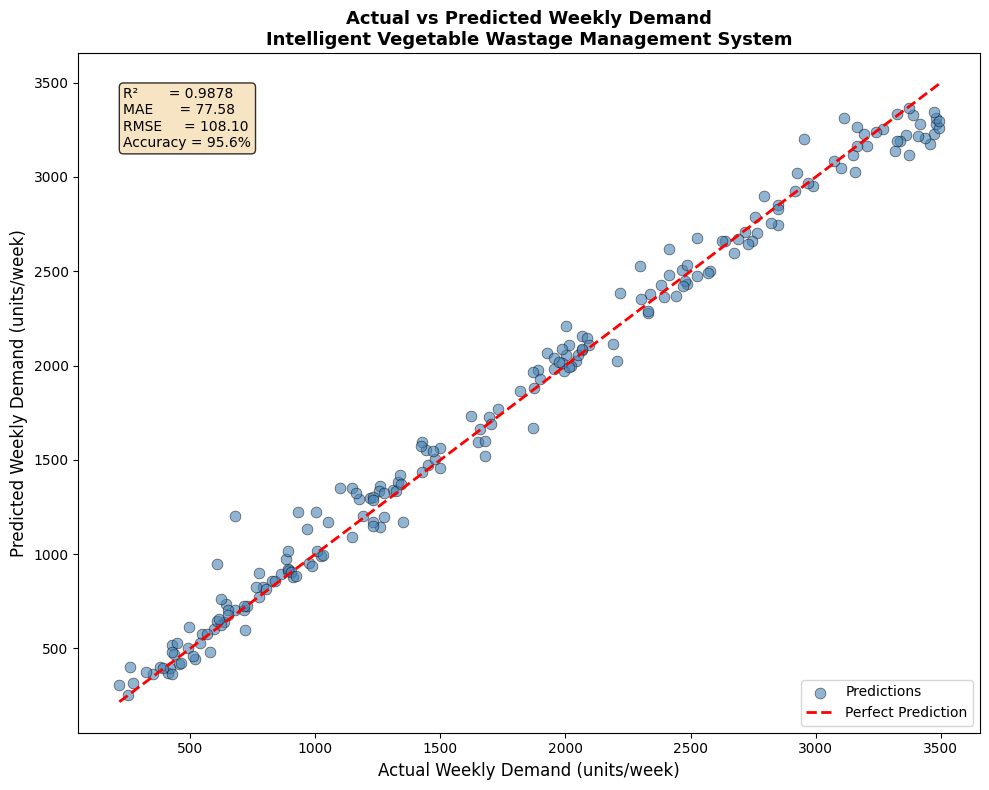

Saved: step8_actual_vs_predicted.png

STEP 9: FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
Rank   Feature                        Importance
------------------------------------------------
1      stock_demand_ratio                 0.4353
2      price_demand_ratio                 0.3493
3      available_stock                    0.1116
4      supply_demand_gap                  0.0637
5      price                              0.0314
6      shelf_life_days                    0.0012
7      vegetable                          0.0012
8      freshness_pct_remaining            0.0010
9      freshness_age                      0.0009
10     life_used_ratio                    0.0008


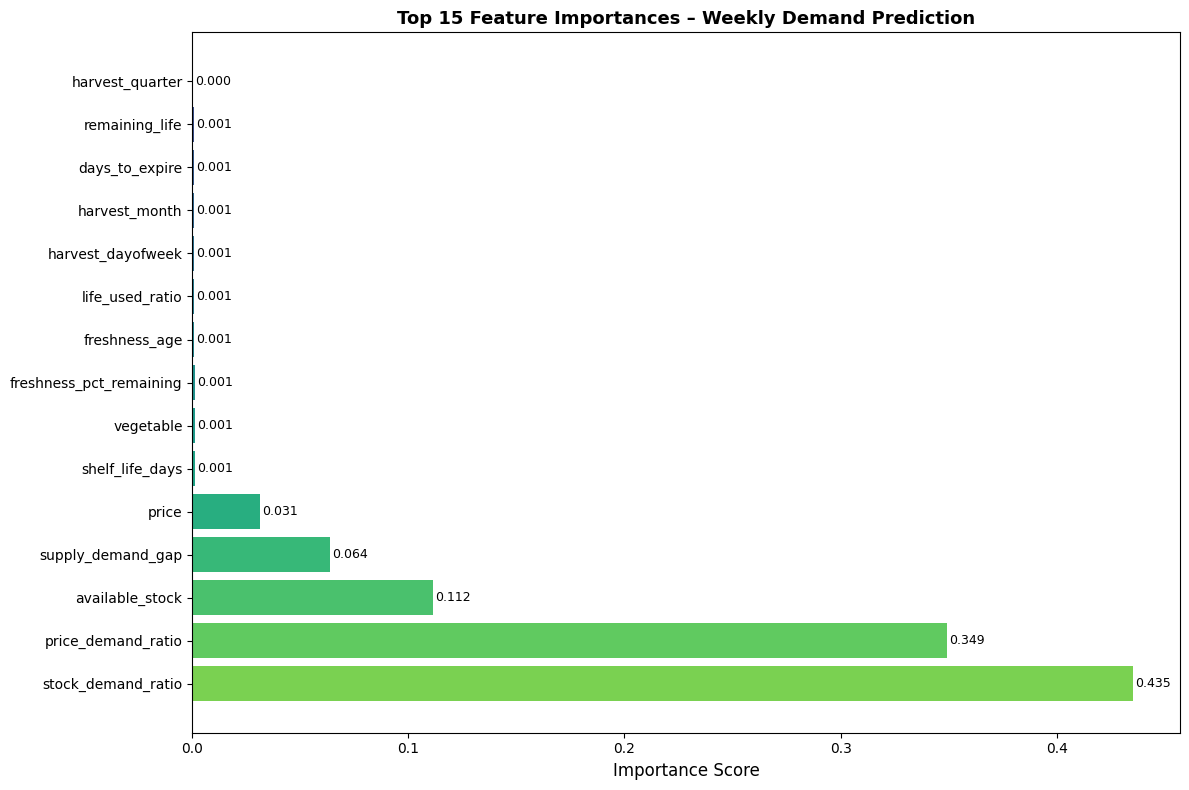

Saved: step9_feature_importance.png

CSVs saved: feature_importance.csv, prediction_results.csv

Cell 1 complete. Run Cell 2 for wastage risk analysis.


In [7]:
# ============================================================
# IT2021 AIML Project
# Intelligent Vegetable Wastage Management System
# Feature  : AI/ML Based Weekly Vegetable Demand Prediction
# Student  : IT24100896  (Pethara)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

print('=' * 60)
print('INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM')
print('AI/ML – WEEKLY DEMAND PREDICTION MODEL')
print('Student : IT24100896')
print('=' * 60)

# ── Load dataset ──────────────────────────────────────────────
df      = pd.read_csv('IT24101661_engineered_dataset.csv')   # Corrected filename
df_orig = df.copy()

le_vegetable = LabelEncoder()
le_vegetable.fit(df['vegetable'])

print(f'\nDataset shape : {df.shape}')

# ============================================================
# STEP 1 : CREATE WEEKLY DEMAND TARGET
# ============================================================
print('\n' + '=' * 60)
print('STEP 1: CREATE WEEKLY DEMAND TARGET')
print('=' * 60)

df['weekly_demand'] = df['daily_demand'] * 7

print(f'\nWeekly demand statistics:')
print(f'  Min  : {df["weekly_demand"].min():.0f} units/week')
print(f'  Max  : {df["weekly_demand"].max():.0f} units/week')
print(f'  Mean : {df["weekly_demand"].mean():.1f} units/week')
print(f'  Std  : {df["weekly_demand"].std():.1f} units/week')

# ============================================================
# STEP 2 : DEFINE FEATURES (X) AND TARGET (y)
# ============================================================
print('\n' + '=' * 60)
print('STEP 2: DEFINE FEATURES AND TARGET')
print('=' * 60)

drop_cols = [
    'weekly_demand',
    'daily_demand',
    'wastage_risk',
    'wastage_risk_enc',
    'country_label',
    'vegetable_label',
    'predicted_14day_demand',
    'stock_after_14days',
    'shortage_in_14days',
    'potential_wastage_units',
    'Predicted_Wastage_Risk',
    'Predicted_Weekly_Demand',
]

X = df.drop(columns=drop_cols, errors='ignore')
y = df['weekly_demand']

print(f'\nTarget variable  : weekly_demand (units/week)')
print(f'Feature count    : {len(X.columns)}')
print(f'\nFeatures used for training:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')
print(f'\nX shape : {X.shape}')
print(f'y shape : {y.shape}')

# ============================================================
# STEP 3 : TRAIN / TEST SPLIT  (80 % / 20 %)
# ============================================================
print('\n' + '=' * 60)
print('STEP 3: TRAIN / TEST SPLIT  (80% / 20%)')
print('=' * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'\nTrain weekly demand mean : {y_train.mean():.1f} units/week')
print(f'Test  weekly demand mean : {y_test.mean():.1f} units/week')

# ============================================================
# STEP 4 : TRAIN MODEL
# ============================================================
print('\n' + '=' * 60)
print('STEP 4: MODEL TRAINING – RandomForestRegressor')
print('=' * 60)

print('\nModel Configuration:')
print('  Algorithm    : Random Forest Regressor')
print('  n_estimators : 150 trees')
print('  random_state : 42')
print('  n_jobs       : -1 (use all CPU cores)')

model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print('\nModel training completed successfully!')

# ============================================================
# STEP 5 : PREDICTIONS
# ============================================================
print('\n' + '=' * 60)
print('STEP 5: WEEKLY DEMAND PREDICTIONS')
print('=' * 60)

y_pred = model.predict(X_test)

print('\nFirst 10 weekly demand predictions:')
print(f'{"#":<5} {"Actual (week)":>14} {"Predicted (week)":>17} {"Error":>10}')
print('-' * 48)
for i in range(10):
    err = y_test.values[i] - y_pred[i]
    print(f'{i+1:<5} {y_test.values[i]:>14.0f} {y_pred[i]:>17.1f} {err:>10.1f}')

# ============================================================
# STEP 6 : EVALUATION METRICS
# ============================================================
print('\n' + '=' * 60)
print('STEP 6: MODEL EVALUATION METRICS')
print('=' * 60)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

nonzero_mask  = y_test != 0
mape          = np.mean(np.abs(
    (y_test[nonzero_mask] - y_pred[nonzero_mask]) / y_test[nonzero_mask]
)) * 100
accuracy_pct  = max(0, min(100, (1 - mae / y_test.mean()) * 100))

print(f'\n{"=" * 45}')
print('  EVALUATION RESULTS  (Weekly Demand)')
print(f'{"=" * 45}')
print(f'  MAE      : {mae:.4f} units/week')
print(f'  MSE      : {mse:.4f}')
print(f'  RMSE     : {rmse:.4f} units/week')
print(f'  R²       : {r2:.4f}')
print(f'  MAPE     : {mape:.2f}%')
print(f'  Accuracy : {accuracy_pct:.2f}%')
print(f'{"=" * 45}')

# ── Expose objects needed by the wastage cell ─────────────────
# (these stay in kernel memory; Cell 2 uses them directly)
print('\nObjects available for Cell 2: model, df, df_orig, le_vegetable,')
print('X, X_test, y_test, y_pred, mae, rmse, r2, mape, accuracy_pct')

# ============================================================
# STEP 7 : BUILD RESULTS TABLE  (used by wastage cell)
# ============================================================
print('\n' + '=' * 60)
print('STEP 7: PREDICTION RESULTS TABLE')
print('=' * 60)

veg_names = le_vegetable.inverse_transform(X_test['vegetable'].values)

X_test_copy = X_test.copy().reset_index(drop=True)
X_test_copy['predicted_weekly_demand'] = y_pred.round(2)
X_test_copy['stock_after_week']        = (
    X_test_copy['available_stock'] - X_test_copy['predicted_weekly_demand']
)

results_df = pd.DataFrame({
    'Vegetable'               : veg_names,
    'Actual_Weekly_Demand'    : y_test.values.astype(int),
    'Predicted_Weekly_Demand' : y_pred.round(2),
    'Prediction_Error'        : (y_test.values - y_pred).round(2),
    'Absolute_Error'          : np.abs(y_test.values - y_pred).round(2),
    'Error_Percentage'        : np.where(
        y_test.values != 0,
        (np.abs(y_test.values - y_pred) / y_test.values * 100), 0
    ).round(2),
    'Remaining_Life'          : X_test['remaining_life'].values.astype(int),
    'Stock_After_Week'        : X_test_copy['stock_after_week'].round(2).values,
}).reset_index(drop=True)

print(f'\nFirst 15 predictions:')
print(f'{"#":<4} {"Vegetable":<14} {"Actual":>8} {"Predicted":>10} {"Error":>8}')
print('-' * 50)
for i, row in results_df.head(15).iterrows():
    print(f'{i+1:<4} {row["Vegetable"]:<14} '
          f'{row["Actual_Weekly_Demand"]:>8} '
          f'{row["Predicted_Weekly_Demand"]:>10.1f} '
          f'{row["Prediction_Error"]:>8.1f}')

# ============================================================
# STEP 8 : VISUALIZATION – ACTUAL VS PREDICTED
# ============================================================
print('\n' + '=' * 60)
print('STEP 8: VISUALIZATION – ACTUAL VS PREDICTED')
print('=' * 60)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='black',
            linewidth=0.5, s=60, color='steelblue', label='Predictions')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Weekly Demand (units/week)', fontsize=12)
plt.ylabel('Predicted Weekly Demand (units/week)', fontsize=12)
plt.title('Actual vs Predicted Weekly Demand\n'
          'Intelligent Vegetable Wastage Management System',
          fontsize=13, fontweight='bold')
plt.legend()
plt.text(0.05, 0.95,
         f'R²       = {r2:.4f}\n'
         f'MAE      = {mae:.2f}\n'
         f'RMSE     = {rmse:.2f}\n'
         f'Accuracy = {accuracy_pct:.1f}%',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
plt.savefig('step8_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step8_actual_vs_predicted.png')

# ============================================================
# STEP 9 : FEATURE IMPORTANCE
# ============================================================
print('\n' + '=' * 60)
print('STEP 9: FEATURE IMPORTANCE ANALYSIS')
print('=' * 60)

feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\nTop 10 Most Important Features:')
print(f'{"Rank":<6} {"Feature":<30} {"Importance":>10}')
print('-' * 48)
for i, row in feature_importance.head(10).iterrows():
    print(f'{i+1:<6} {row["Feature"]:<30} {row["Importance"]:>10.4f}')

top_features = feature_importance.head(15)
plt.figure(figsize=(12, 8))
bars = plt.barh(
    range(len(top_features)),
    top_features['Importance'].values,
    color=plt.cm.viridis(np.linspace(0.8, 0.2, len(top_features)))
)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importances – Weekly Demand Prediction',
          fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_features['Importance'].values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('step9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step9_feature_importance.png')

# ── Save CSVs ─────────────────────────────────────────────────
feature_importance.to_csv('feature_importance.csv', index=False)
results_df.to_csv('prediction_results.csv', index=False)
print('\nCSVs saved: feature_importance.csv, prediction_results.csv')

print('\n' + '=' * 60)
print('Cell 1 complete. Run Cell 2 for wastage risk analysis.')
print('=' * 60)

INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM
WASTAGE RISK CALCULATION – IT24101709

STEP 1: WASTAGE RISK CLASSIFICATION LOGIC

Classification thresholds:
  remaining_life <= 1  →  High   (almost expired – act immediately)
  remaining_life <= 5  →  Medium (expiring soon – discount / move)
  remaining_life >  5  →  Low    (still fresh – normal operations)

STEP 2: DEFINE 5 VEGETABLE SCENARIOS FROM DATASET

Vegetable      Stock  Daily Demand  Remaining Life  Shelf Life  Price (LKR)
--------------------------------------------------------------
Tomato           398           215              1d         24d       116.93
Carrot           533           225              2d          9d       155.07
Spinach          494            74              8d         11d        82.28
Green Bean        79           312              5d         14d       113.58
Cabbage          173           316             23d         24d       197.52

STEP 3: WASTAGE CALCULATION PER VEGETABLE

──────────────────────────

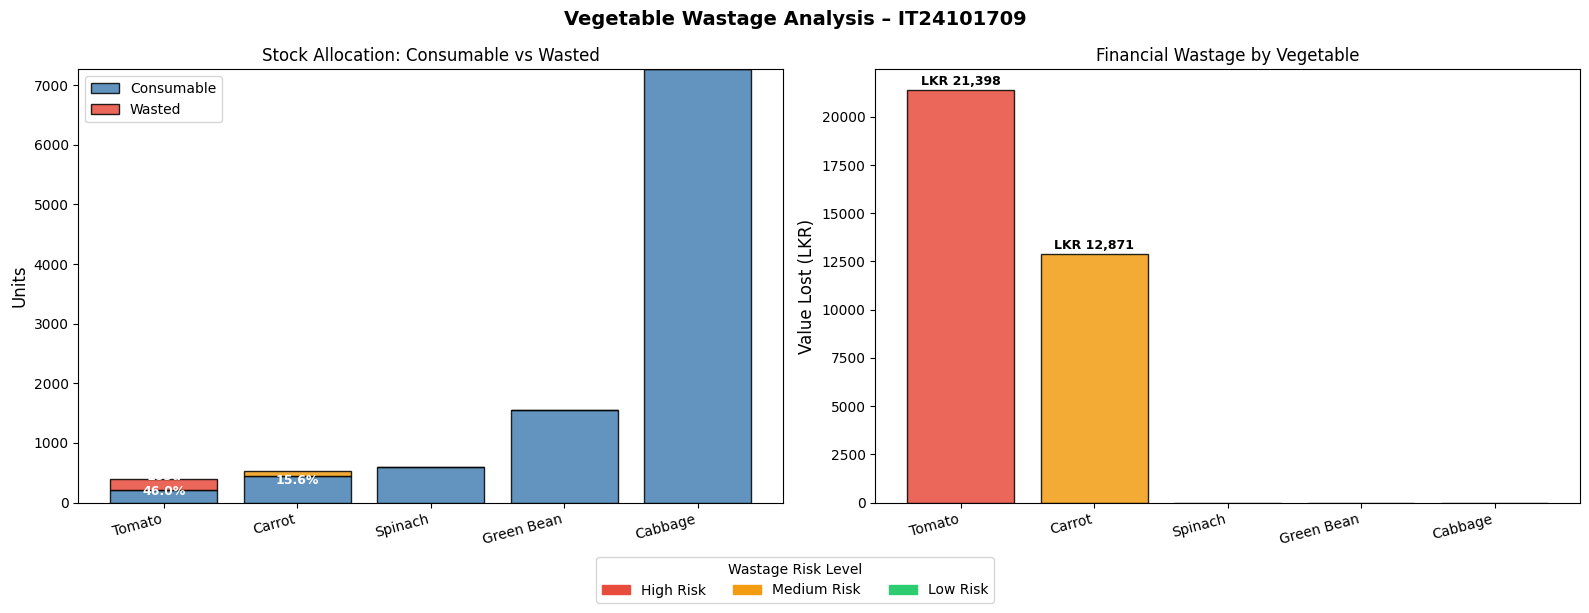

Saved: step6_wastage_breakdown.png

STEP 7: VISUALIZATION – SHELF LIFE USAGE


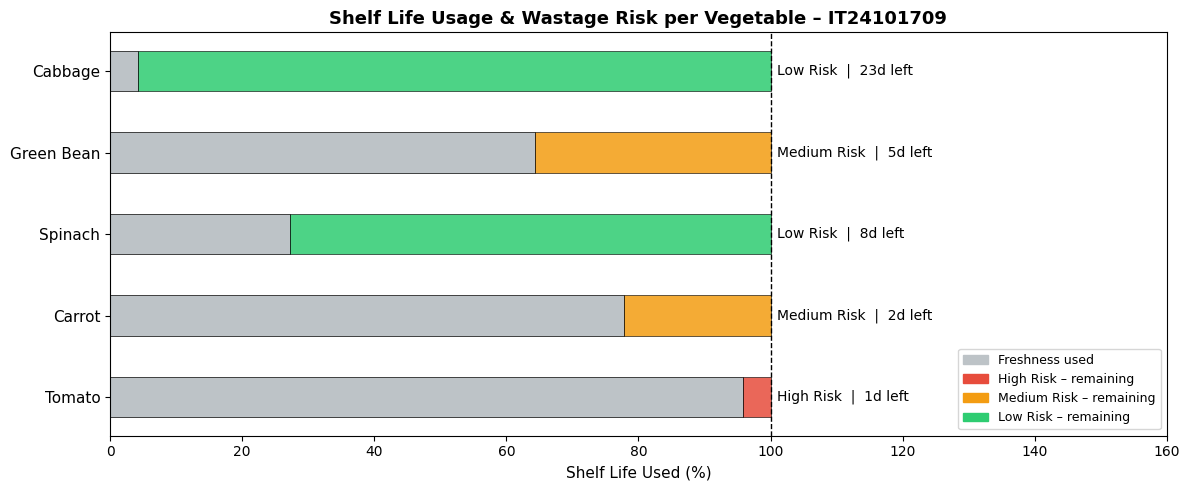

Saved: step7_shelf_life_gauge.png

STEP 8: VISUALIZATION – RISK DISTRIBUTION


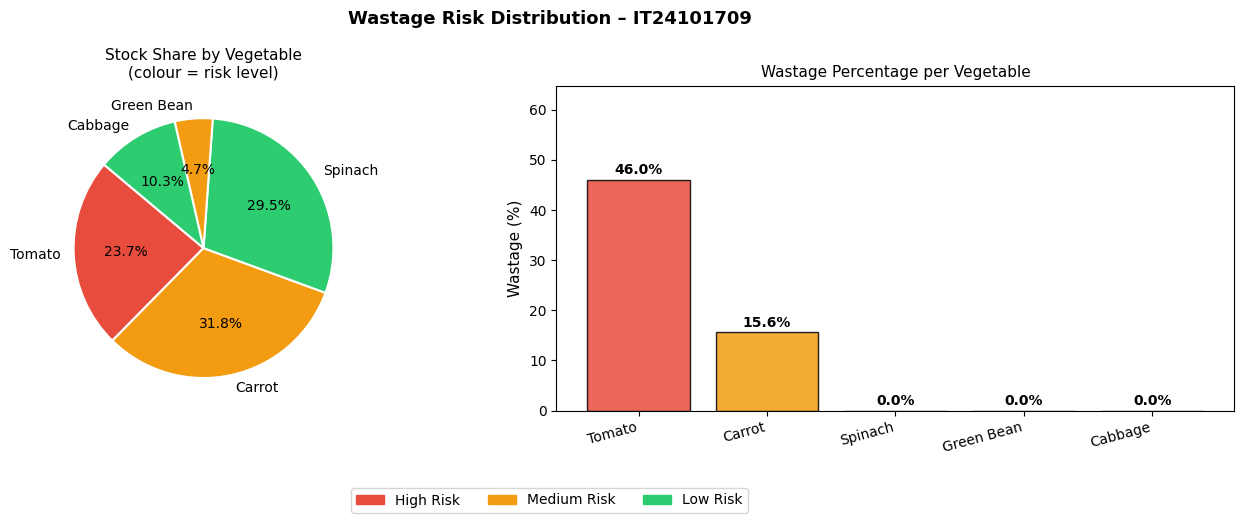

Saved: step8_risk_distribution.png

WASTAGE ANALYSIS – FINAL SUMMARY

╔══════════════════════════════════════════════════════════════╗
║   INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM           ║
║   Wastage Risk Calculation  –  IT24101709                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║   WASTAGE FORMULA                                           ║
║   consumable = daily_demand × remaining_life                ║
║   wastage    = max(0, available_stock − consumable)         ║
║   value_lost = wastage × price_per_unit                     ║
║                                                              ║
║   RISK THRESHOLDS                                           ║
║   High   : remaining_life <= 1 day                         ║
║   Medium : remaining_life <= 5 days                        ║
║   Low    : remaining_life >  5 days                        ║
║                                

In [8]:

# Intelligent Vegetable Wastage Management System
# Feature  : Vegetable-Specific Wastage Risk Calculation
# Student  : IT24101709

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('=' * 60)
print('INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM')
print('WASTAGE RISK CALCULATION – IT24101709')
print('=' * 60)


# STEP 1 : WASTAGE RISK CLASSIFICATION FUNCTION

print('\n' + '=' * 60)
print('STEP 1: WASTAGE RISK CLASSIFICATION LOGIC')
print('=' * 60)

def assign_wastage_risk(remaining_life):
    """
    Classifies wastage risk based on remaining shelf life.

    Parameters:
        remaining_life (int): days of freshness remaining

    Returns:
        str: 'High', 'Medium', or 'Low'
    """
    if remaining_life <= 1:
        return 'High'      # Almost expired – immediate action needed
    elif remaining_life <= 5:
        return 'Medium'    # Expiring soon – reduce stock or discount
    else:
        return 'Low'       # Still fresh – no action needed

print('\nClassification thresholds:')
print('  remaining_life <= 1  →  High   (almost expired – act immediately)')
print('  remaining_life <= 5  →  Medium (expiring soon – discount / move)')
print('  remaining_life >  5  →  Low    (still fresh – normal operations)')


# STEP 2 : DEFINE 5 REAL VEGETABLE SCENARIOS
# Vegetable mapping (encoder index → real name):
#   2 → Tomato     | 4 → Carrot   | 9 → Spinach
#   1 → Green Bean | 8 → Cabbage
#
# Wastage formula:
#   consumable_units = daily_demand × remaining_life
#   wastage_units    = max(0, available_stock − consumable_units)
#   wastage_pct      = (wastage_units / available_stock) × 100
#   wastage_value    = wastage_units × price_per_unit

print('\n' + '=' * 60)
print('STEP 2: DEFINE 5 VEGETABLE SCENARIOS FROM DATASET')
print('=' * 60)

vegetables = [
    {
        'name'           : 'Tomato',
        'veg_enc'        : 2,
        'available_stock': 398,    # units currently in store
        'daily_demand'   : 215,    # avg units sold per day
        'remaining_life' : 1,      # days left before spoilage
        'shelf_life_days': 24,     # original total shelf life
        'price_per_unit' : 116.93, # LKR per unit
    },
    {
        'name'           : 'Carrot',
        'veg_enc'        : 4,
        'available_stock': 533,
        'daily_demand'   : 225,
        'remaining_life' : 2,
        'shelf_life_days': 9,
        'price_per_unit' : 155.07,
    },
    {
        'name'           : 'Spinach',
        'veg_enc'        : 9,
        'available_stock': 494,
        'daily_demand'   : 74,
        'remaining_life' : 8,
        'shelf_life_days': 11,
        'price_per_unit' : 82.28,
    },
    {
        'name'           : 'Green Bean',
        'veg_enc'        : 1,
        'available_stock': 79,
        'daily_demand'   : 312,
        'remaining_life' : 5,
        'shelf_life_days': 14,
        'price_per_unit' : 113.58,
    },
    {
        'name'           : 'Cabbage',
        'veg_enc'        : 8,
        'available_stock': 173,
        'daily_demand'   : 316,
        'remaining_life' : 23,
        'shelf_life_days': 24,
        'price_per_unit' : 197.52,
    },
]

print(f'\n{"Vegetable":<12} {"Stock":>7} {"Daily Demand":>13} '
      f'{"Remaining Life":>15} {"Shelf Life":>11} {"Price (LKR)":>12}')
print('-' * 62)
for v in vegetables:
    print(f'{v["name"]:<12} {v["available_stock"]:>7} {v["daily_demand"]:>13} '
          f'{v["remaining_life"]:>14}d {v["shelf_life_days"]:>10}d '
          f'{v["price_per_unit"]:>12.2f}')


# STEP 3 : CALCULATE WASTAGE FOR EACH VEGETABLE

print('\n' + '=' * 60)
print('STEP 3: WASTAGE CALCULATION PER VEGETABLE')
print('=' * 60)

RISK_COLORS = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}

results = []

for v in vegetables:
    consumable = v['daily_demand'] * v['remaining_life']
    wastage    = max(0, v['available_stock'] - consumable)
    shortage   = max(0, consumable - v['available_stock'])
    wastage_pct= (wastage / v['available_stock'] * 100) if v['available_stock'] > 0 else 0
    value_lost = wastage * v['price_per_unit']
    risk       = assign_wastage_risk(v['remaining_life'])
    freshness_used = ((v['shelf_life_days'] - v['remaining_life']) /
                       v['shelf_life_days'] * 100)

    entry = {
        **v,
        'consumable_units': consumable,
        'wastage_units'   : wastage,
        'shortage_units'  : shortage,
        'wastage_pct'     : round(wastage_pct, 1),
        'value_lost_lkr'  : round(value_lost, 2),
        'risk'            : risk,
        'freshness_used'  : round(freshness_used, 1),
    }
    results.append(entry)

    print(f'\n{"─" * 55}')
    print(f'  Vegetable       : {v["name"]}')
    print(f'  Available Stock : {v["available_stock"]} units')
    print(f'  Daily Demand    : {v["daily_demand"]} units/day')
    print(f'  Remaining Life  : {v["remaining_life"]} day(s)')
    print(f'  Shelf Life      : {v["shelf_life_days"]} days  '
          f'(freshness used: {freshness_used:.1f}%)')
    print(f'  ── Calculation ──────────────────────────────')
    print(f'  Consumable Units: {v["daily_demand"]} × {v["remaining_life"]} '
          f'= {consumable} units')
    print(f'  Wastage Units   : max(0, {v["available_stock"]} − {consumable}) '
          f'= {wastage} units')
    if shortage > 0:
        print(f'  Stock Shortage  : {shortage} units  '
              f'(demand exceeds stock – no wastage)')
    print(f'  Wastage %       : {wastage_pct:.1f}%')
    print(f'  Value Lost      : LKR {value_lost:,.2f}')
    print(f'  Wastage Risk    : {risk}')

print(f'\n{"─" * 55}')


# STEP 4 : SUMMARY TABLE

print('\n' + '=' * 60)
print('STEP 4: WASTAGE SUMMARY TABLE')
print('=' * 60)

summary_df = pd.DataFrame([{
    'Vegetable'       : r['name'],
    'Stock'           : r['available_stock'],
    'Daily Demand'    : r['daily_demand'],
    'Remaining (days)': r['remaining_life'],
    'Wastage (units)' : r['wastage_units'],
    'Wastage %'       : r['wastage_pct'],
    'Value Lost (LKR)': r['value_lost_lkr'],
    'Risk'            : r['risk'],
} for r in results])

print(f'\n{summary_df.to_string(index=False)}')

total_wastage_units = sum(r['wastage_units'] for r in results)
total_value_lost    = sum(r['value_lost_lkr'] for r in results)
print(f'\n  Total wastage units : {total_wastage_units}')
print(f'  Total value lost    : LKR {total_value_lost:,.2f}')


# STEP 5 : RISK VALIDATION (vs. assign_wastage_risk)

print('\n' + '=' * 60)
print('STEP 5: RISK CLASSIFICATION VALIDATION')
print('=' * 60)

print(f'\n{"Vegetable":<12} {"Remaining Life":>15} {"Assigned Risk":>14}')
print('-' * 44)
for r in results:
    print(f'{r["name"]:<12} {r["remaining_life"]:>13}d  {r["risk"]:>14}')

risk_counts = {}
for r in results:
    risk_counts[r['risk']] = risk_counts.get(r['risk'], 0) + 1
print(f'\nRisk distribution across 5 vegetables:')
for lvl in ['High', 'Medium', 'Low']:
    print(f'  {lvl:<8} : {risk_counts.get(lvl, 0)} vegetable(s)')


# STEP 6 : VISUALIZATION – WASTAGE BREAKDOWN BAR CHART

print('\n' + '=' * 60)
print('STEP 6: VISUALIZATION – WASTAGE BREAKDOWN')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Vegetable Wastage Analysis – IT24101709',
             fontsize=14, fontweight='bold')

# ── Left: Stacked bar – stock allocation ──────────────────────
names      = [r['name']             for r in results]
sold       = [r['consumable_units'] for r in results]
wasted     = [r['wastage_units']    for r in results]
bar_colors = [RISK_COLORS[r['risk']] for r in results]

x = np.arange(len(names))
bars_sold   = axes[0].bar(x, sold,   label='Consumable',
                           color='steelblue', edgecolor='black', alpha=0.85)
bars_wasted = axes[0].bar(x, wasted, bottom=sold,
                           label='Wasted', color=bar_colors,
                           edgecolor='black', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylabel('Units', fontsize=12)
axes[0].set_title('Stock Allocation: Consumable vs Wasted', fontsize=12)
axes[0].legend()

for bar, r in zip(bars_wasted, results):
    if r['wastage_units'] > 0:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2,
            f'{r["wastage_units"]}u\n{r["wastage_pct"]}%',
            ha='center', va='center', fontsize=9,
            fontweight='bold', color='white'
        )

# ── Right: Value lost per vegetable ───────────────────────────
values     = [r['value_lost_lkr'] for r in results]
bar_colors2= [RISK_COLORS[r['risk']] for r in results]
bars_val   = axes[1].bar(names, values, color=bar_colors2,
                          edgecolor='black', alpha=0.85)

axes[1].set_ylabel('Value Lost (LKR)', fontsize=12)
axes[1].set_title('Financial Wastage by Vegetable', fontsize=12)
axes[1].set_xticklabels(names, rotation=15, ha='right')

for bar, val in zip(bars_val, values):
    if val > 0:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'LKR {val:,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

# Shared risk legend
patches = [mpatches.Patch(color=c, label=f'{k} Risk')
           for k, c in RISK_COLORS.items()]
fig.legend(handles=patches, loc='lower center',
           ncol=3, fontsize=10, frameon=True,
           title='Wastage Risk Level', bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('step6_wastage_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step6_wastage_breakdown.png')


# STEP 7 : VISUALIZATION – REMAINING LIFE vs RISK GAUGE

print('\n' + '=' * 60)
print('STEP 7: VISUALIZATION – SHELF LIFE USAGE')
print('=' * 60)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Shelf Life Usage & Wastage Risk per Vegetable – IT24101709',
             fontsize=13, fontweight='bold')

y_pos = np.arange(len(results))

for i, r in enumerate(results):
    used_pct = r['freshness_used']
    rem_pct  = 100 - used_pct

    # Used portion
    ax.barh(i, used_pct, color='#bdc3c7', edgecolor='black',
            linewidth=0.5, height=0.5)
    # Remaining portion
    ax.barh(i, rem_pct, left=used_pct,
            color=RISK_COLORS[r['risk']], edgecolor='black',
            linewidth=0.5, height=0.5, alpha=0.85)

    ax.text(101, i, f'{r["risk"]} Risk  |  {r["remaining_life"]}d left',
            va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels([r['name'] for r in results], fontsize=11)
ax.set_xlabel('Shelf Life Used (%)', fontsize=11)
ax.set_xlim(0, 160)
ax.axvline(x=100, color='black', linestyle='--', linewidth=1)

grey_patch = mpatches.Patch(color='#bdc3c7', label='Freshness used')
patches2   = [grey_patch] + [
    mpatches.Patch(color=c, label=f'{k} Risk – remaining')
    for k, c in RISK_COLORS.items()
]
ax.legend(handles=patches2, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('step7_shelf_life_gauge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step7_shelf_life_gauge.png')


# STEP 8 : RISK DISTRIBUTION PIE CHART
print('\n' + '=' * 60)
print('STEP 8: VISUALIZATION – RISK DISTRIBUTION')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Wastage Risk Distribution – IT24101709',
             fontsize=13, fontweight='bold')

# Pie – 5 vegetables
pie_labels = [r['name'] for r in results]
pie_colors = [RISK_COLORS[r['risk']] for r in results]
pie_sizes  = [r['available_stock'] for r in results]

axes[0].pie(pie_sizes, labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Stock Share by Vegetable\n(colour = risk level)',
                  fontsize=11)

# Bar – wastage % per vegetable
wastage_pcts = [r['wastage_pct'] for r in results]
axes[1].bar(names, wastage_pcts, color=pie_colors,
            edgecolor='black', alpha=0.85)
axes[1].set_ylabel('Wastage (%)', fontsize=11)
axes[1].set_title('Wastage Percentage per Vegetable', fontsize=11)
axes[1].set_ylim(0, max(wastage_pcts) * 1.3 + 5)
axes[1].set_xticklabels(names, rotation=15, ha='right')
for i, (pct, bar) in enumerate(
        zip(wastage_pcts, axes[1].patches)):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{pct}%', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('step8_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step8_risk_distribution.png')


# FINAL SUMMARY

print('\n' + '=' * 60)
print('WASTAGE ANALYSIS – FINAL SUMMARY')
print('=' * 60)
print(f"""
╔══════════════════════════════════════════════════════════════╗
║   INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM           ║
║   Wastage Risk Calculation  –  IT24101709                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║   WASTAGE FORMULA                                           ║
║   consumable = daily_demand × remaining_life                ║
║   wastage    = max(0, available_stock − consumable)         ║
║   value_lost = wastage × price_per_unit                     ║
║                                                              ║
║   RISK THRESHOLDS                                           ║
║   High   : remaining_life <= 1 day                         ║
║   Medium : remaining_life <= 5 days                        ║
║   Low    : remaining_life >  5 days                        ║
║                                                              ║
║   RESULTS (5 VEGETABLES)                                    ║""")
for r in results:
    line = (f'║   {r["name"]:<12} | Risk: {r["risk"]:<6} | '
            f'Wastage: {r["wastage_units"]:>4}u ({r["wastage_pct"]:>5.1f}%) | '
            f'LKR {r["value_lost_lkr"]:>8,.0f}')
    print(f'{line:<64}║')
print(f'║                                                              ║')
print(f'║   Total wastage units : {total_wastage_units:<6}                            ║')
print(f'║   Total value at risk : LKR {total_value_lost:>10,.2f}                    ║')
print(f'╚══════════════════════════════════════════════════════════════╝')

# ── Save results ──────────────────────────────────────────────
summary_df.to_csv('wastage_results.csv', index=False)
print('\nSaved: wastage_results.csv')
print('\nCell 2 complete.')

INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM
MODEL EVALUATION & VISUALIZATIONS – IT24101083

SETUP: RECALCULATE METRICS & BUILD RESULTS TABLE

Results table built successfully.
Rows: 200  |  Columns: ['Vegetable', 'Actual_Weekly_Demand', 'Predicted_Weekly_Demand', 'Prediction_Error', 'Absolute_Error', 'Error_Percentage']

First 10 rows:
 Vegetable  Actual_Weekly_Demand  Predicted_Weekly_Demand  Prediction_Error  Absolute_Error  Error_Percentage
         4                  1260                  1361.13           -101.13          101.13              8.03
         3                   455                   418.79             36.21           36.21              7.96
         5                  2849                  2851.05             -2.05            2.05              0.07
         4                  2674                  2599.57             74.43           74.43              2.78
         0                  3458                  3174.22            283.78          283.78              8.2

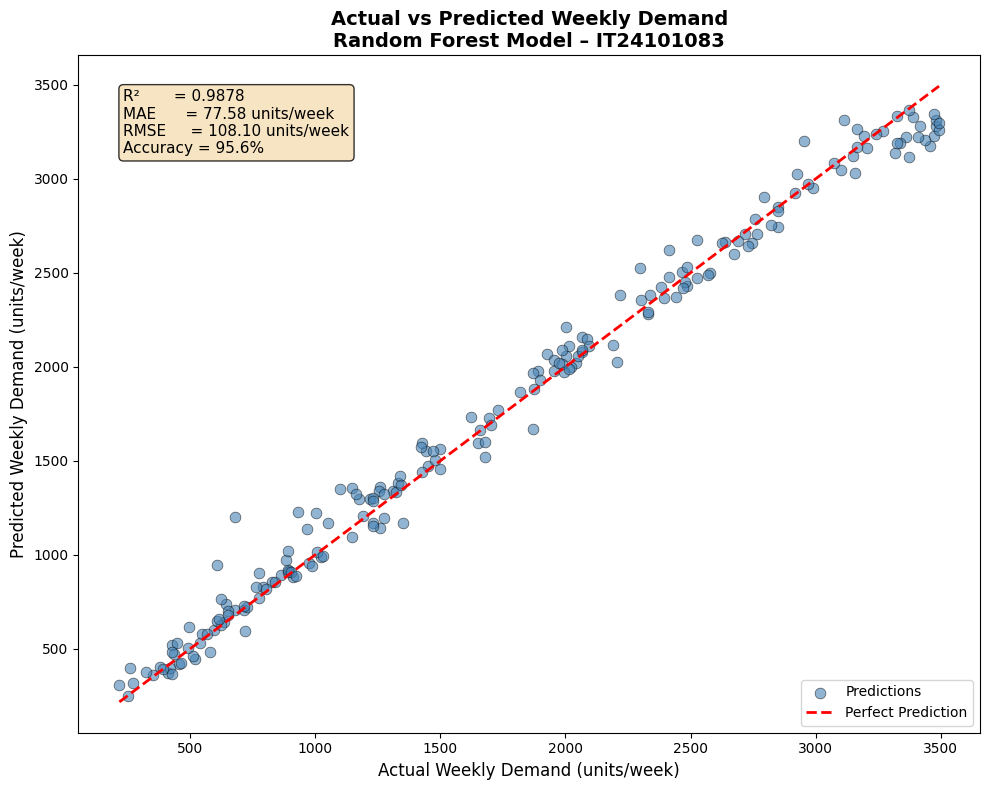

Saved: step10_actual_vs_predicted.png

STEP 11: VISUALIZATION – ERROR DISTRIBUTION


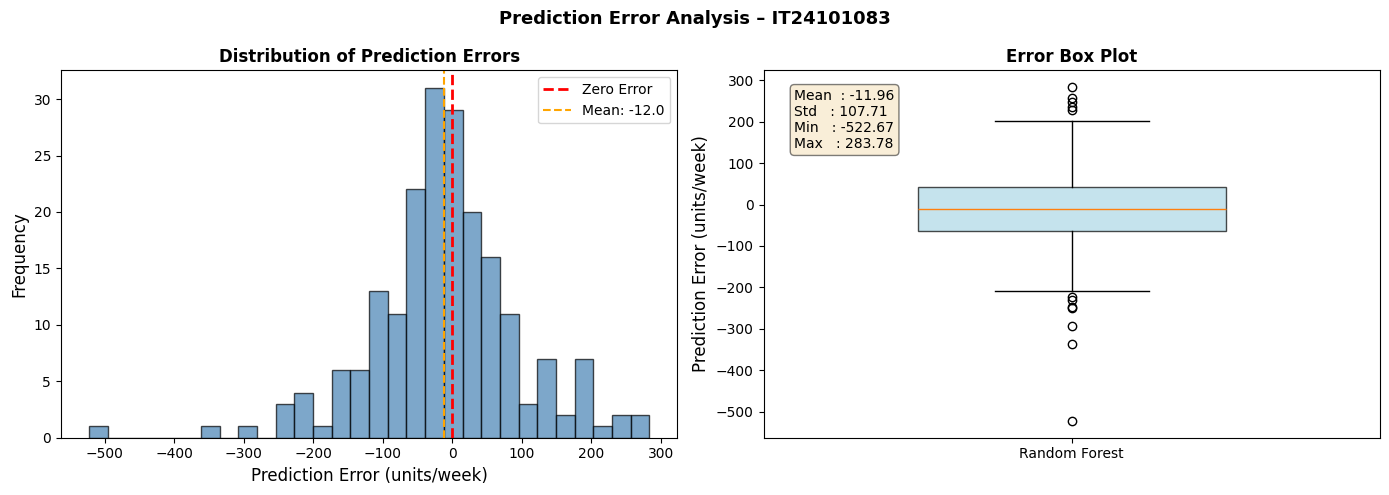

Saved: step11_error_distribution.png

Error Statistics:
  Mean Error    : -11.9606 units/week
  Std Deviation : 107.7097
  Min Error     : -522.6700
  Max Error     : 283.7800

STEP 12: VISUALIZATION – WEEKLY DEMAND LINE CHART


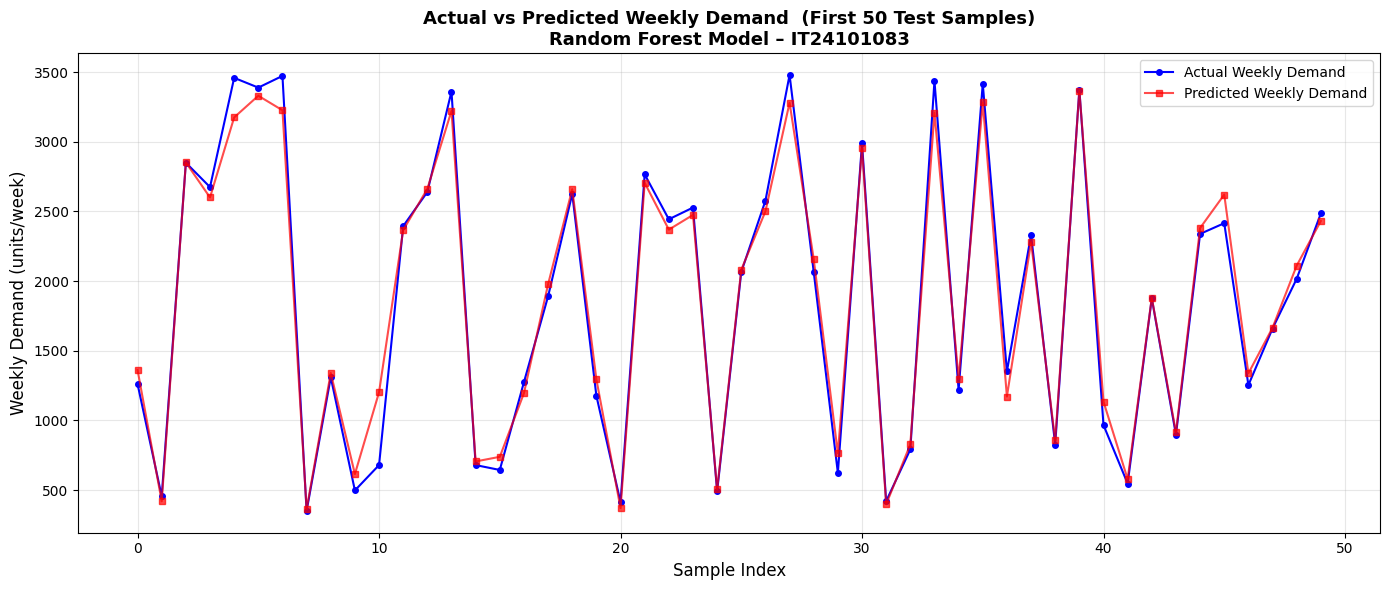

Saved: step12_line_comparison.png

STEP 13: FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
Rank   Feature                        Importance
------------------------------------------------
1      stock_demand_ratio                 0.4353
2      price_demand_ratio                 0.3493
3      available_stock                    0.1116
4      supply_demand_gap                  0.0637
5      price                              0.0314
6      shelf_life_days                    0.0012
7      vegetable                          0.0012
8      freshness_pct_remaining            0.0010
9      freshness_age                      0.0009
10     life_used_ratio                    0.0008


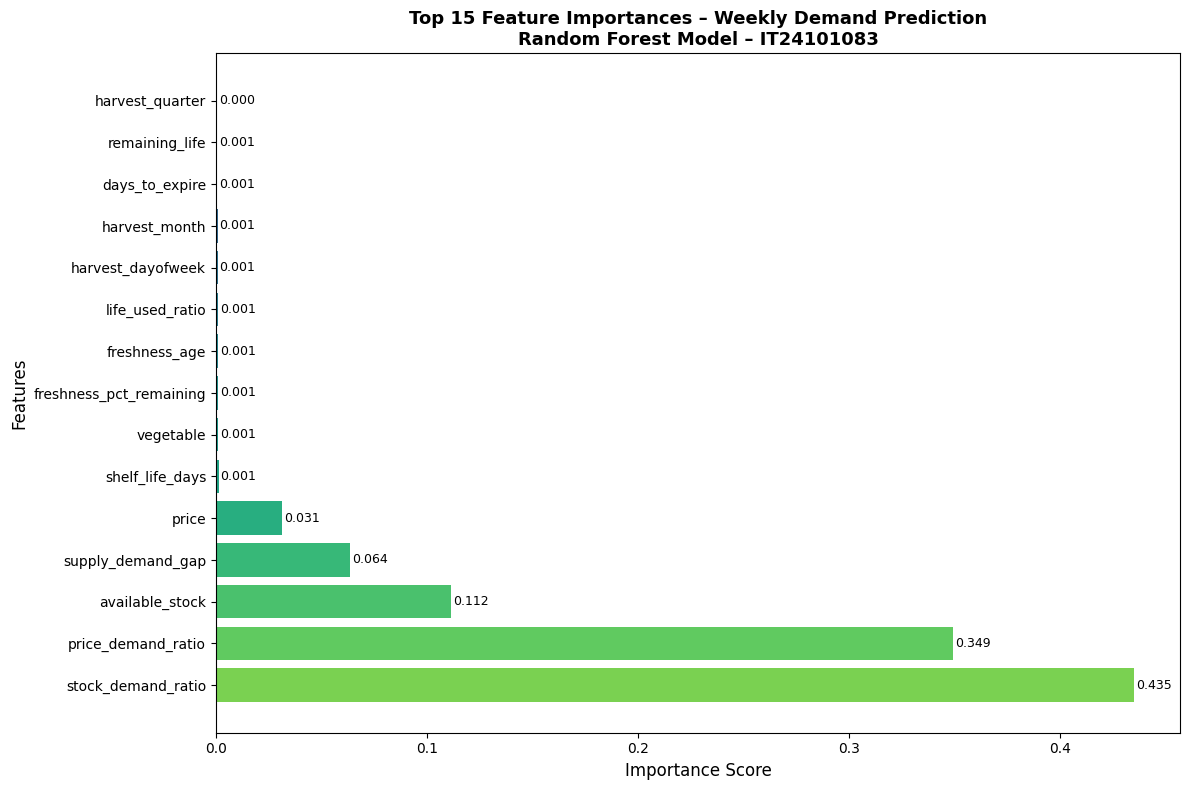

Saved: step13_feature_importance.png

STEP 14: VISUALIZATION – RESIDUAL PLOT


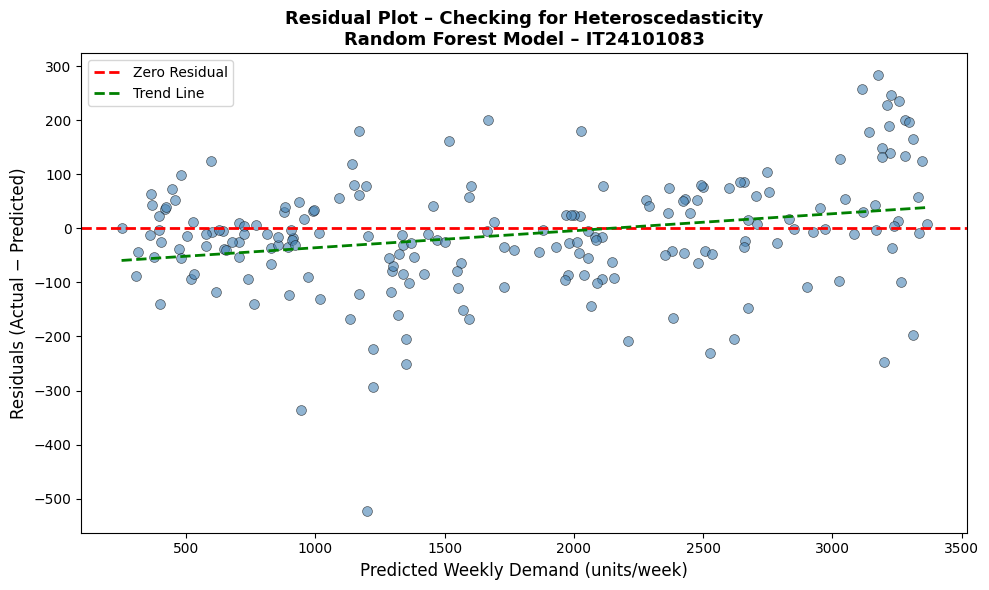

Saved: step14_residual_plot.png

STEP 15: ERROR ANALYSIS BY VEGETABLE TYPE

Weekly Demand Error Summary by Vegetable:
           Mean_Absolute_Error  Std_Absolute_Error  Mean_Error_Percentage  Count
Vegetable                                                                       
9                       112.97              115.07                  10.48     25
4                        94.94               82.89                   7.05     16
0                        86.58               89.18                   6.13     27
1                        79.95               65.64                   6.01     19
2                        77.33               68.95                   5.71     22
5                        72.10               70.55                   3.81     18
7                        69.67               58.01                   7.09     18
6                        68.08               51.89                   3.66     18
8                        52.18               45.52                   4.3

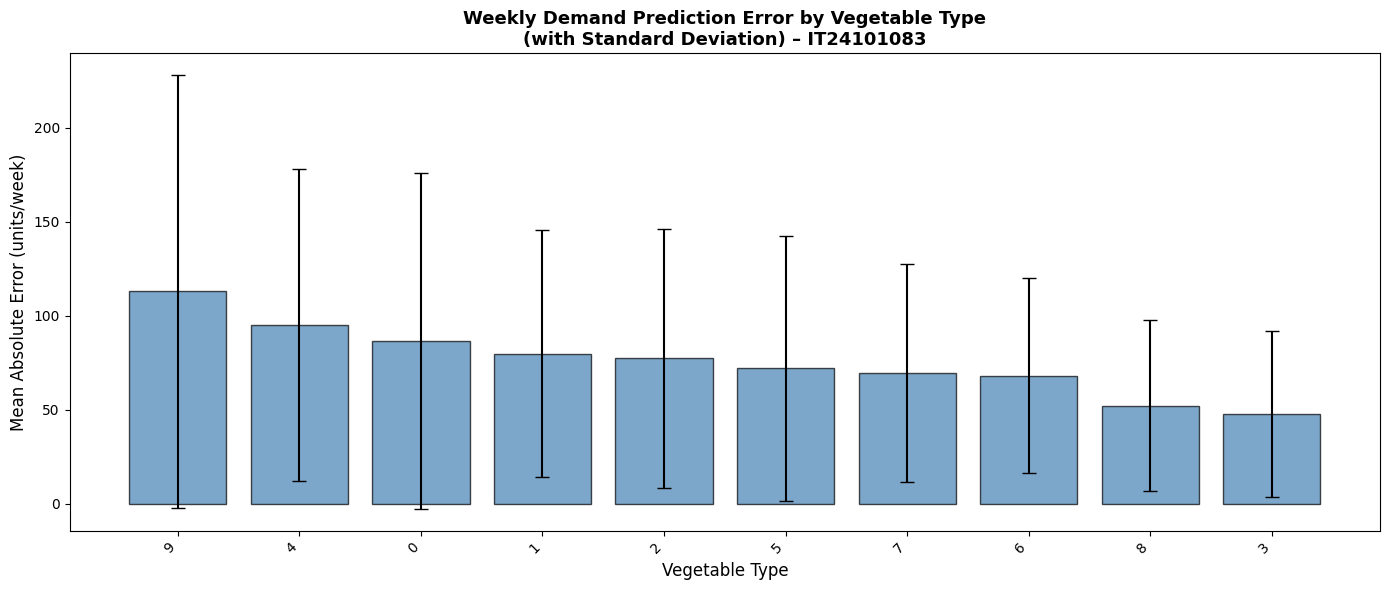

Saved: step15_error_by_vegetable.png

MODEL EVALUATION SUMMARY – IT24101083

╔══════════════════════════════════════════════════════════╗
║         MODEL PERFORMANCE SUMMARY  –  IT24101083        ║
╠══════════════════════════════════════════════════════════╣
║  Mean Absolute Error (MAE)       : 77.5850              ║
║  Mean Squared Error  (MSE)       : 11686.3749           ║
║  Root Mean Squared Error (RMSE)  : 108.1035             ║
║  R-squared (R²)                  : 0.9878               ║
║  Mean Abs Percentage Error(MAPE) : 6.32      %          ║
║  Model Accuracy (approx)         : 95.56     %          ║
╠══════════════════════════════════════════════════════════╣
║  Training samples : 800                                ║
║  Testing  samples : 200                                ║
║  Number of features : 18                               ║
╚══════════════════════════════════════════════════════════╝

Top 3 Most Important Features:
  1. stock_demand_ratio             (43.5%)
  2. p

In [9]:
# ============================================================
# IT2021 AIML Project
# Intelligent Vegetable Wastage Management System
# Feature  : Model Evaluation & Visualizations
# Student  : IT24101083
# ============================================================
# RUNS AFTER : Cell 1 (IT24100896 – model training)
# REQUIRES   : model, X, X_test, y_test, y_pred,
#              le_vegetable  (from Cell 1)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('=' * 60)
print('INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM')
print('MODEL EVALUATION & VISUALIZATIONS – IT24101083')
print('=' * 60)

# ============================================================
# SETUP : RECALCULATE METRICS & BUILD RESULTS TABLE
# ============================================================
print('\n' + '=' * 60)
print('SETUP: RECALCULATE METRICS & BUILD RESULTS TABLE')
print('=' * 60)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

nonzero_mask = y_test != 0
mape         = np.mean(np.abs(
    (y_test[nonzero_mask] - y_pred[nonzero_mask]) /
     y_test[nonzero_mask]
)) * 100
accuracy_pct = max(0, min(100, (1 - mae / y_test.mean()) * 100))

veg_names  = le_vegetable.inverse_transform(X_test['vegetable'].values)

results_df = pd.DataFrame({
    'Vegetable'               : veg_names,
    'Actual_Weekly_Demand'    : y_test.values,
    'Predicted_Weekly_Demand' : y_pred.round(2),
    'Prediction_Error'        : (y_test.values - y_pred).round(2),
    'Absolute_Error'          : np.abs(y_test.values - y_pred).round(2),
    'Error_Percentage'        : np.where(
        y_test.values != 0,
        (np.abs(y_test.values - y_pred) / y_test.values * 100), 0
    ).round(2),
}).reset_index(drop=True)

print('\nResults table built successfully.')
print(f'Rows: {len(results_df)}  |  Columns: {list(results_df.columns)}')
print('\nFirst 10 rows:')
print(results_df.head(10).to_string(index=False))

# ============================================================
# STEP 10 : ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================
print('\n' + '=' * 60)
print('STEP 10: VISUALIZATION – ACTUAL VS PREDICTED SCATTER')
print('=' * 60)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='black',
            linewidth=0.5, s=60, color='steelblue',
            label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Weekly Demand (units/week)', fontsize=12)
plt.ylabel('Predicted Weekly Demand (units/week)', fontsize=12)
plt.title('Actual vs Predicted Weekly Demand\n'
          'Random Forest Model – IT24101083',
          fontsize=14, fontweight='bold')
plt.legend()
plt.text(
    0.05, 0.95,
    f'R²       = {r2:.4f}\n'
    f'MAE      = {mae:.2f} units/week\n'
    f'RMSE     = {rmse:.2f} units/week\n'
    f'Accuracy = {accuracy_pct:.1f}%',
    transform=plt.gca().transAxes, fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)
plt.tight_layout()
plt.savefig('step10_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step10_actual_vs_predicted.png')

# ============================================================
# STEP 11 : ERROR DISTRIBUTION  (Histogram + Box Plot)
# ============================================================
print('\n' + '=' * 60)
print('STEP 11: VISUALIZATION – ERROR DISTRIBUTION')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediction Error Analysis – IT24101083',
             fontsize=13, fontweight='bold')

# ── Histogram ─────────────────────────────────────────────────
axes[0].hist(results_df['Prediction_Error'], bins=30,
             edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero Error')
axes[0].axvline(results_df['Prediction_Error'].mean(),
                color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: {results_df["Prediction_Error"].mean():.1f}')
axes[0].set_xlabel('Prediction Error (units/week)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Errors',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# ── Box plot ──────────────────────────────────────────────────
bp = axes[1].boxplot([results_df['Prediction_Error']],
                      patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_ylabel('Prediction Error (units/week)', fontsize=12)
axes[1].set_title('Error Box Plot', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Random Forest'])

stats_text = (
    f'Mean  : {results_df["Prediction_Error"].mean():.2f}\n'
    f'Std   : {results_df["Prediction_Error"].std():.2f}\n'
    f'Min   : {results_df["Prediction_Error"].min():.2f}\n'
    f'Max   : {results_df["Prediction_Error"].max():.2f}'
)
axes[1].text(0.05, 0.95, stats_text,
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('step11_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step11_error_distribution.png')

print(f'\nError Statistics:')
print(f'  Mean Error    : {results_df["Prediction_Error"].mean():.4f} units/week')
print(f'  Std Deviation : {results_df["Prediction_Error"].std():.4f}')
print(f'  Min Error     : {results_df["Prediction_Error"].min():.4f}')
print(f'  Max Error     : {results_df["Prediction_Error"].max():.4f}')

# ============================================================
# STEP 12 : ACTUAL VS PREDICTED LINE CHART  (first 50 samples)
# ============================================================
print('\n' + '=' * 60)
print('STEP 12: VISUALIZATION – WEEKLY DEMAND LINE CHART')
print('=' * 60)

sample_size = min(50, len(results_df))
indices     = np.arange(sample_size)

plt.figure(figsize=(14, 6))
plt.plot(indices,
         results_df['Actual_Weekly_Demand'].values[:sample_size],
         marker='o', markersize=4, linewidth=1.5,
         label='Actual Weekly Demand', color='blue')
plt.plot(indices,
         results_df['Predicted_Weekly_Demand'].values[:sample_size],
         marker='s', markersize=4, linewidth=1.5,
         label='Predicted Weekly Demand', color='red', alpha=0.7)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Weekly Demand (units/week)', fontsize=12)
plt.title(f'Actual vs Predicted Weekly Demand  '
          f'(First {sample_size} Test Samples)\n'
          f'Random Forest Model – IT24101083',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('step12_line_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step12_line_comparison.png')

# ============================================================
# STEP 13 : FEATURE IMPORTANCE
# ============================================================
print('\n' + '=' * 60)
print('STEP 13: FEATURE IMPORTANCE ANALYSIS')
print('=' * 60)

feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\nTop 10 Most Important Features:')
print(f'{"Rank":<6} {"Feature":<30} {"Importance":>10}')
print('-' * 48)
for i, row in feature_importance.head(10).iterrows():
    print(f'{i+1:<6} {row["Feature"]:<30} {row["Importance"]:>10.4f}')

top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    range(len(top_features)),
    top_features['Importance'].values,
    color=plt.cm.viridis(np.linspace(0.8, 0.2, len(top_features)))
)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 Feature Importances – Weekly Demand Prediction\n'
          'Random Forest Model – IT24101083',
          fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_features['Importance'].values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('step13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step13_feature_importance.png')

# ============================================================
# STEP 14 : RESIDUAL PLOT
# ============================================================
print('\n' + '=' * 60)
print('STEP 14: VISUALIZATION – RESIDUAL PLOT')
print('=' * 60)

residuals = results_df['Prediction_Error'].values

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6,
            edgecolors='black', linewidth=0.5,
            s=50, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--',
            linewidth=2, label='Zero Residual')

z = np.polyfit(y_pred, residuals, 1)
p = np.poly1d(z)
plt.plot(np.sort(y_pred), p(np.sort(y_pred)),
         'g--', linewidth=2, label='Trend Line')

plt.xlabel('Predicted Weekly Demand (units/week)', fontsize=12)
plt.ylabel('Residuals (Actual − Predicted)', fontsize=12)
plt.title('Residual Plot – Checking for Heteroscedasticity\n'
          'Random Forest Model – IT24101083',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('step14_residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step14_residual_plot.png')

# ============================================================
# STEP 15 : ERROR ANALYSIS BY VEGETABLE TYPE
# ============================================================
print('\n' + '=' * 60)
print('STEP 15: ERROR ANALYSIS BY VEGETABLE TYPE')
print('=' * 60)

veg_error_summary = results_df.groupby('Vegetable').agg(
    Mean_Absolute_Error  =('Absolute_Error',         'mean'),
    Std_Absolute_Error   =('Absolute_Error',         'std'),
    Mean_Error_Percentage=('Error_Percentage',       'mean'),
    Count                =('Actual_Weekly_Demand',   'count'),
).round(2).sort_values('Mean_Absolute_Error', ascending=False)

print('\nWeekly Demand Error Summary by Vegetable:')
print(veg_error_summary.to_string())

x_pos       = np.arange(len(veg_error_summary))
errors_plot = veg_error_summary['Mean_Absolute_Error'].values
error_bars  = veg_error_summary['Std_Absolute_Error'].fillna(0).values

plt.figure(figsize=(14, 6))
plt.bar(x_pos, errors_plot, yerr=error_bars, capsize=5,
        color='steelblue', alpha=0.7, edgecolor='black')
plt.xticks(x_pos, veg_error_summary.index.tolist(),
           rotation=45, ha='right')
plt.xlabel('Vegetable Type', fontsize=12)
plt.ylabel('Mean Absolute Error (units/week)', fontsize=12)
plt.title('Weekly Demand Prediction Error by Vegetable Type\n'
          '(with Standard Deviation) – IT24101083',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step15_error_by_vegetable.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step15_error_by_vegetable.png')

# ============================================================
# MODEL EVALUATION SUMMARY
# ============================================================
print('\n' + '=' * 60)
print('MODEL EVALUATION SUMMARY – IT24101083')
print('=' * 60)

try:
    train_samples = len(y_train)
except NameError:
    train_samples = 'N/A'

print(f"""
╔══════════════════════════════════════════════════════════╗
║         MODEL PERFORMANCE SUMMARY  –  IT24101083        ║
╠══════════════════════════════════════════════════════════╣
║  Mean Absolute Error (MAE)       : {mae:<10.4f}           ║
║  Mean Squared Error  (MSE)       : {mse:<10.4f}           ║
║  Root Mean Squared Error (RMSE)  : {rmse:<10.4f}           ║
║  R-squared (R²)                  : {r2:<10.4f}           ║
║  Mean Abs Percentage Error(MAPE) : {mape:<10.2f}%          ║
║  Model Accuracy (approx)         : {accuracy_pct:<10.2f}%          ║
╠══════════════════════════════════════════════════════════╣
║  Training samples : {str(train_samples):<10}                         ║
║  Testing  samples : {len(y_test):<10}                         ║
║  Number of features : {X.shape[1]:<10}                       ║
╚══════════════════════════════════════════════════════════╝
""")

top_3 = feature_importance.head(3)['Feature'].tolist()
print('Top 3 Most Important Features:')
for i, feat in enumerate(top_3, 1):
    imp = feature_importance.loc[i - 1, 'Importance']
    print(f'  {i}. {feat:<30} ({imp:.1%})')

# ============================================================
# STEP 16 : SAVE ALL RESULTS
# ============================================================
print('\n' + '=' * 60)
print('STEP 16: SAVING MODEL EVALUATION RESULTS')
print('=' * 60)

feature_importance.to_csv('feature_importance_IT24101083.csv', index=False)
print('Saved: feature_importance_IT24101083.csv')

results_df.to_csv('prediction_results_IT24101083.csv', index=False)
print('Saved: prediction_results_IT24101083.csv')

pd.DataFrame([{
    'Student' : 'IT24101083',
    'Model'   : 'RandomForestRegressor',
    'MAE'     : round(mae,  4),
    'MSE'     : round(mse,  4),
    'RMSE'    : round(rmse, 4),
    'R2'      : round(r2,   4),
    'MAPE'    : round(mape, 2),
    'Accuracy': round(accuracy_pct, 2),
}]).to_csv('model_metrics_IT24101083.csv', index=False)
print('Saved: model_metrics_IT24101083.csv')

print('\nAll files saved successfully!')

try:
    from google.colab import files
    files.download('feature_importance_IT24101083.csv')
    files.download('prediction_results_IT24101083.csv')
    files.download('model_metrics_IT24101083.csv')
except ImportError:
    print('(Not in Colab – files saved locally.)')

print('\n' + '=' * 60)
print('Cell 3 complete.')
print('=' * 60)

INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM
FULL PIPELINE – IT24102412

STEP 1: DATA PREPROCESSING
Missing values after handling: 0
Duplicates removed: 0
Date features already exist — skipping date conversion
Dataset shape after preprocessing: (1000, 25)

STEP 2: FEATURE ENGINEERING
Feature engineering completed!
Total features: 26

Weekly demand statistics:
  Min  : 210 units/week
  Max  : 3493 units/week
  Mean : 1820.7 units/week

STEP 3: ENCODING CATEGORICAL VARIABLES
Country already encoded — encoder rebuilt from labels
Vegetable already encoded — encoder rebuilt from labels
wastage_risk derived from wastage_risk_enc: {0: 'High', 1: 'Low', 2: 'Medium'}

STEP 4: PREPARING FEATURES AND TARGET
Target variable : weekly_demand (units/week)
Features shape  : (1000, 19)
Target shape    : (1000,)

Feature names:
   1. country
   2. vegetable
   3. price
   4. available_stock
   5. freshness_age
   6. shelf_life_days
   7. remaining_life
   8. supply_demand_gap
   9. harvest_month
  10

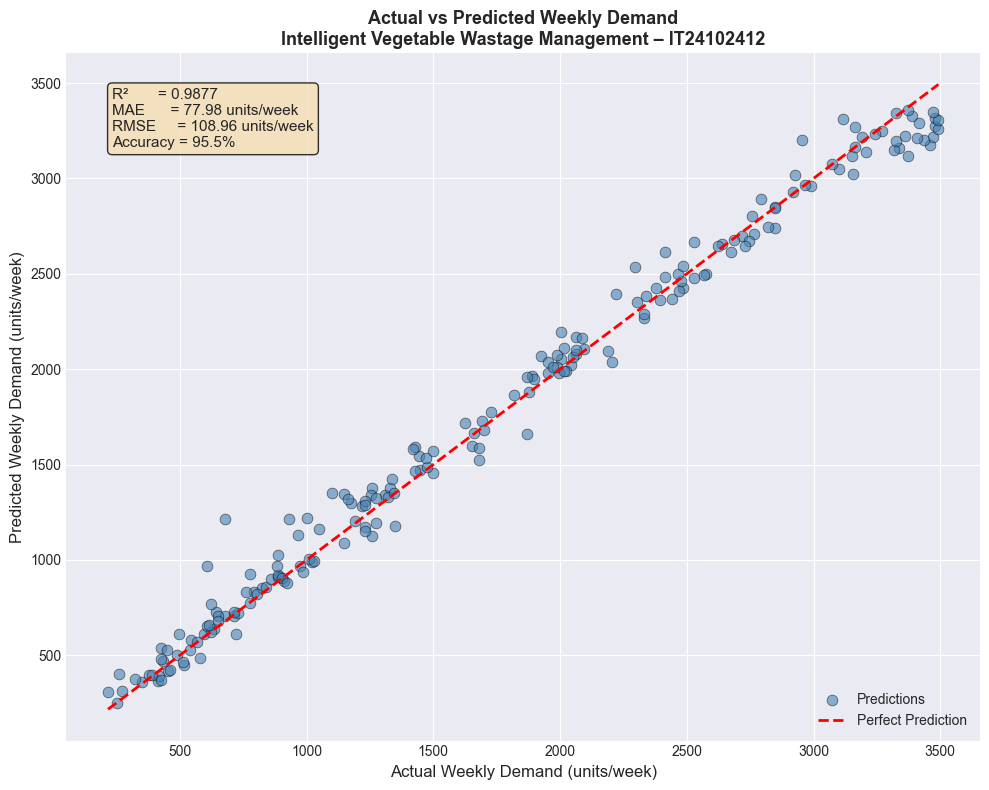

Saved: step10_actual_vs_predicted_IT24102412.png

STEP 11: VISUALIZATION – ERROR DISTRIBUTION


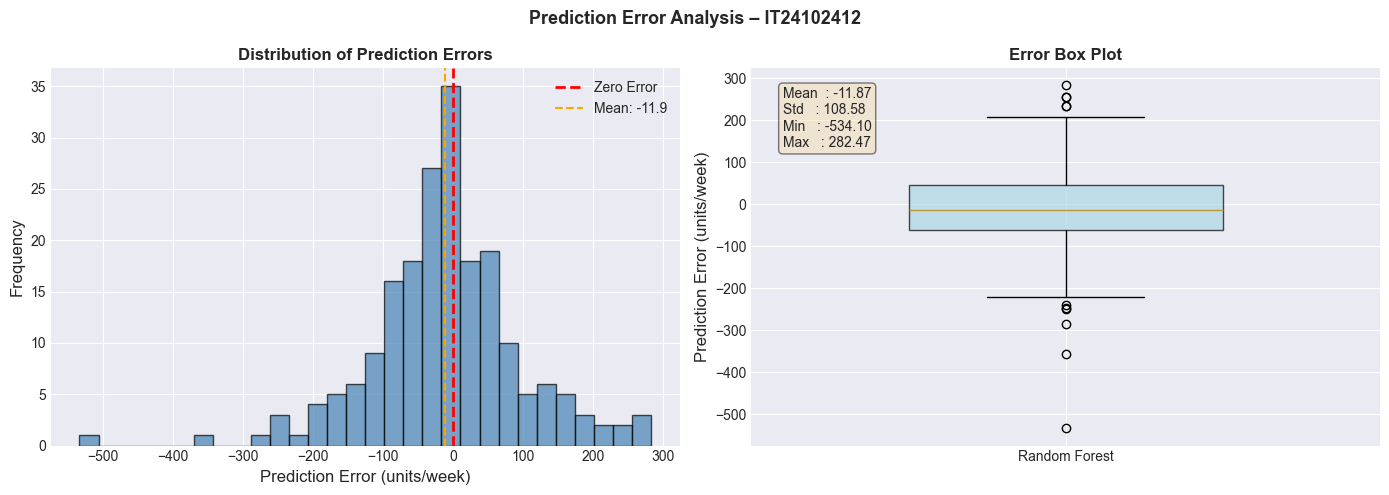

Saved: step11_error_distribution_IT24102412.png

Error Statistics:
  Mean Error    : -11.8690 units/week
  Std Deviation : 108.5787
  Min Error     : -534.1000
  Max Error     : 282.4700

STEP 12: VISUALIZATION – WEEKLY DEMAND LINE CHART


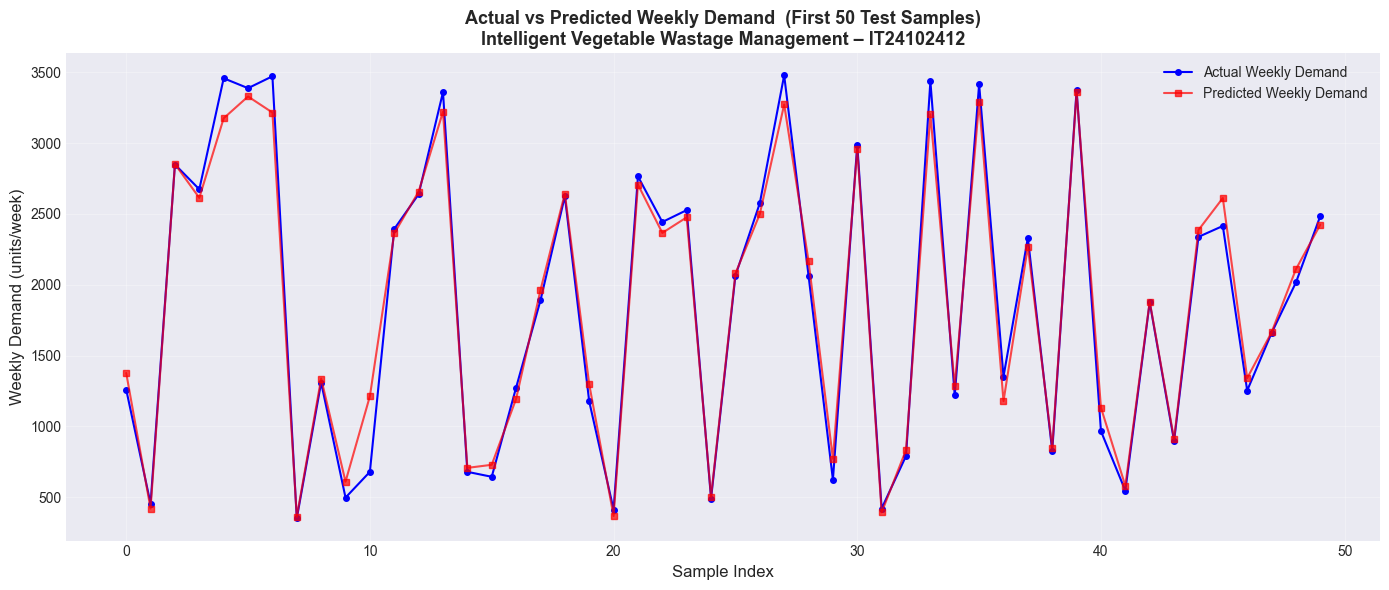

Saved: step12_line_comparison_IT24102412.png

STEP 13: FEATURE IMPORTANCE ANALYSIS
Top 10 Most Important Features:
Rank   Feature                        Importance
------------------------------------------------
1      price_demand_ratio                 0.3491
2      stock_demand_ratio                 0.2384
3      demand_coverage                    0.1981
4      available_stock                    0.1115
5      supply_demand_gap                  0.0629
6      price                              0.0315
7      shelf_life_days                    0.0012
8      vegetable                          0.0012
9      freshness_pct_remaining            0.0010
10     freshness_age                      0.0009


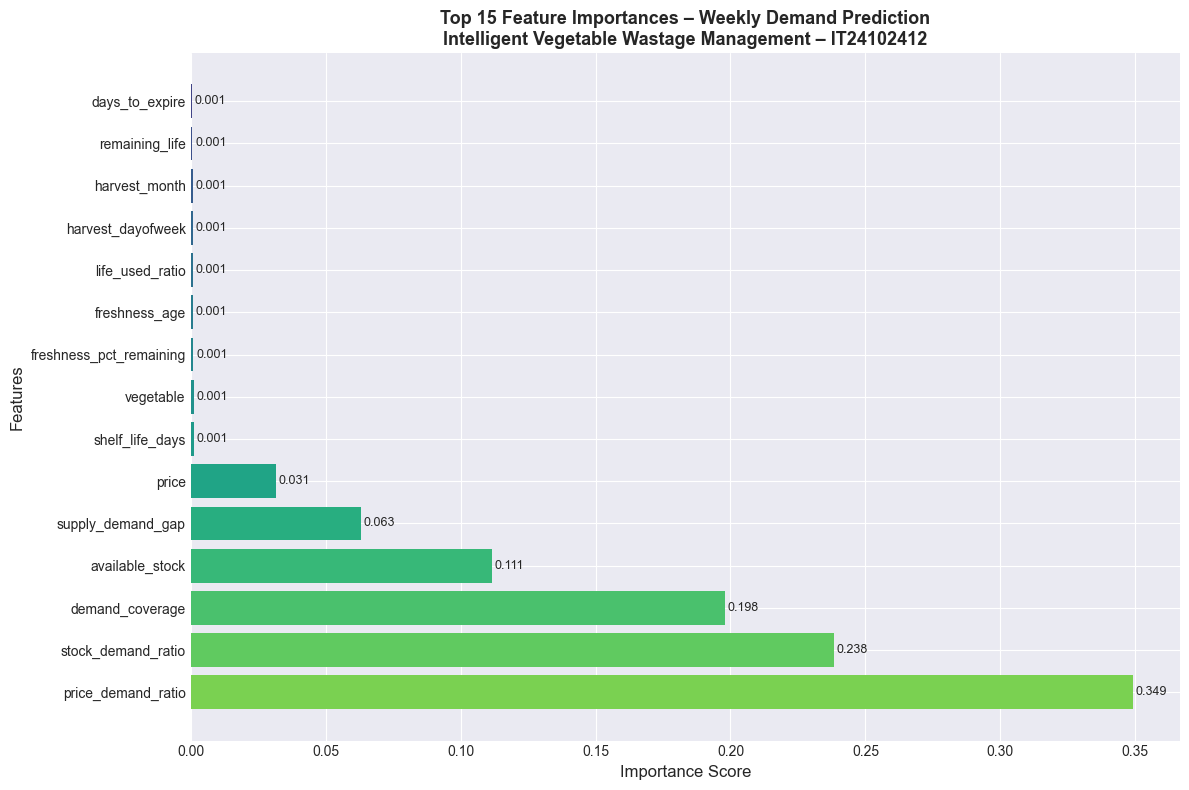

Saved: step13_feature_importance_IT24102412.png

STEP 14: VISUALIZATION – RESIDUAL PLOT


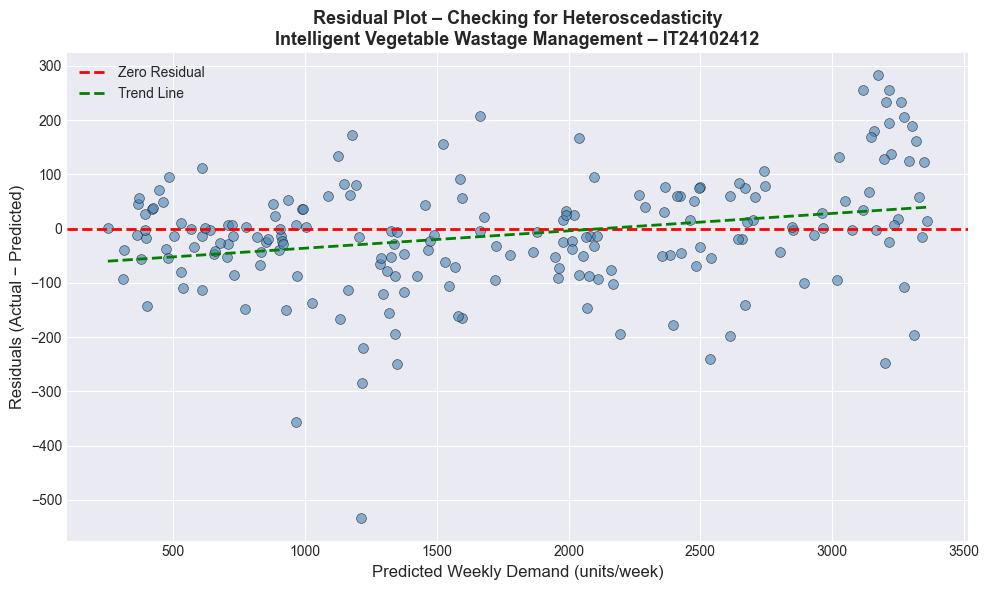

Saved: step14_residual_plot_IT24102412.png

STEP 15: ERROR ANALYSIS BY VEGETABLE TYPE

Error Summary by Vegetable Type:
           Mean_Absolute_Error  Std_Absolute_Error  Mean_Error_Percentage  Count
Vegetable                                                                       
9                       114.98              118.05                  10.64     25
4                        94.74               81.63                   6.97     16
0                        87.88               91.45                   6.42     27
1                        78.22               63.82                   5.79     19
2                        76.41               68.90                   5.64     22
5                        73.73               71.26                   3.88     18
7                        70.30               57.36                   7.18     18
6                        69.38               51.28                   3.79     18
8                        51.69               43.40                   4

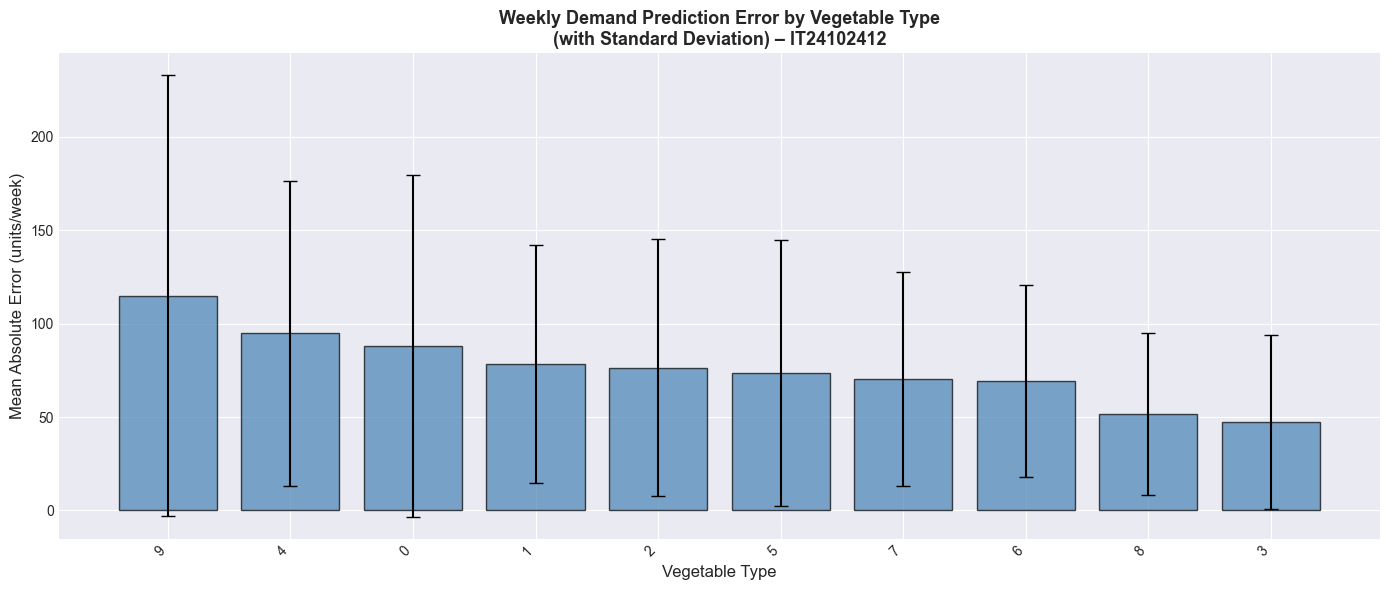

Saved: step15_error_by_vegetable_IT24102412.png

MODEL EVALUATION SUMMARY – IT24102412

╔══════════════════════════════════════════════════════════════╗
║   INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM           ║
║   Model Evaluation  –  IT24102412                           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║   WEEKLY DEMAND PREDICTION (Regression)                     ║
║   Algorithm   : Random Forest Regressor (150 trees)         ║
║   Target      : weekly_demand = daily_demand × 7            ║
║   MAE          : 77.98    units/week avg error           ║
║   RMSE         : 108.96   units/week                    ║
║   R²           : 0.9877   variance explained             ║
║   MAPE         : 6.36    % average % error             ║
║   Accuracy     : 95.54   %                      ║
║                                                              ║
║   DATASET                            

In [10]:
# ============================================================
# IT2021 AIML Project
# Intelligent Vegetable Wastage Management System
# Feature  : Full Pipeline – Preprocessing, Feature Engineering,
#            Model Training & Evaluation Visualizations
# Student  : IT24102412
# ============================================================
# RUNS AFTER : IT24101661 feature engineering cell
# REQUIRES   : df  (engineered DataFrame already in memory)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print('=' * 60)
print('INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM')
print('FULL PIPELINE – IT24102412')
print('=' * 60)

# ============================================================
# STEP 1 : DATA PREPROCESSING
# ============================================================
print('\n' + '=' * 60)
print('STEP 1: DATA PREPROCESSING')
print('=' * 60)

# Handle missing values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values after handling: {df.isnull().sum().sum()}')

# Remove duplicates
before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - df.shape[0]}')

# Date features – only if harvest_date column is present
if 'harvest_date' in df.columns:
    df['harvest_date'] = pd.to_datetime(df['harvest_date'])
    df['harvest_month']      = df['harvest_date'].dt.month
    df['harvest_dayofweek']  = df['harvest_date'].dt.dayofweek
    df['harvest_quarter']    = df['harvest_date'].dt.quarter
    print('Date features added: harvest_month, harvest_dayofweek, harvest_quarter')
else:
    print('Date features already exist — skipping date conversion')

print(f'Dataset shape after preprocessing: {df.shape}')

# ============================================================
# STEP 2 : FEATURE ENGINEERING
# ============================================================
print('\n' + '=' * 60)
print('STEP 2: FEATURE ENGINEERING')
print('=' * 60)

# Demand / stock ratio features
df['stock_demand_ratio'] = df['available_stock'] / (df['daily_demand'] + 1)
df['life_used_ratio']    = df['freshness_age']   / (df['shelf_life_days'] + 1)
df['days_to_expire']     = df['shelf_life_days'] - df['freshness_age']
df['demand_coverage']    = df['available_stock'] / (df['daily_demand'] + 1)

# 14-day projection features
df['predicted_14day_demand'] = df['daily_demand'] * 14
df['stock_after_14days']     = df['available_stock'] - df['predicted_14day_demand']
df['shortage_in_14days']     = (df['stock_after_14days'] < 0).astype(int)
df['potential_wastage_units']= df['stock_after_14days'].clip(lower=0)
df['expires_before_14days']  = (df['days_to_expire'] < 14).astype(int)
df['freshness_pct_remaining']= (
    df['days_to_expire'] / (df['shelf_life_days'] + 1)
) * 100
df['price_demand_ratio']     = df['price'] / (df['daily_demand'] + 1)
df['overstock_flag']         = (
    df['supply_demand_gap'] > df['daily_demand'] * 3
).astype(int)

# Weekly demand target (aligned with IT24100896)
df['weekly_demand'] = df['daily_demand'] * 7

print('Feature engineering completed!')
print(f'Total features: {df.shape[1]}')
print(f'\nWeekly demand statistics:')
print(f'  Min  : {df["weekly_demand"].min():.0f} units/week')
print(f'  Max  : {df["weekly_demand"].max():.0f} units/week')
print(f'  Mean : {df["weekly_demand"].mean():.1f} units/week')

# ============================================================
# STEP 3 : ENCODING CATEGORICAL VARIABLES
# ============================================================
print('\n' + '=' * 60)
print('STEP 3: ENCODING CATEGORICAL VARIABLES')
print('=' * 60)

le_country   = LabelEncoder()
le_vegetable = LabelEncoder()

# Keep human-readable label copies before encoding
df['country_label']   = df['country'].astype(str)
df['vegetable_label'] = df['vegetable'].astype(str)

# Encode only if still string type (guard against double-encoding)
if df['country'].dtype == object:
    df['country']   = le_country.fit_transform(df['country'])
    print('Country classes  :', list(le_country.classes_))
else:
    # Already numeric – rebuild encoder from encoded values for inverse_transform
    le_country.classes_ = np.array(
        sorted(df['country_label'].unique()))
    print('Country already encoded — encoder rebuilt from labels')

if df['vegetable'].dtype == object:
    df['vegetable'] = le_vegetable.fit_transform(df['vegetable'])
    print('Vegetable classes:', list(le_vegetable.classes_))
else:
    le_vegetable.classes_ = np.array(
        sorted(df['vegetable_label'].unique()))
    print('Vegetable already encoded — encoder rebuilt from labels')

# FIX: wastage_risk column does not exist in engineered dataset;
#      wastage_risk_enc is already present — derive risk label from it.
if 'wastage_risk' in df.columns:
    le_risk = LabelEncoder()
    df['wastage_risk_enc'] = le_risk.fit_transform(df['wastage_risk'])
    print('Risk classes     :', list(le_risk.classes_))
else:
    # Map existing numeric encoding back to readable labels
    risk_map = {0: 'High', 1: 'Low', 2: 'Medium'}
    df['wastage_risk'] = df['wastage_risk_enc'].map(risk_map)
    print('wastage_risk derived from wastage_risk_enc:', risk_map)

# ============================================================
# STEP 4 : PREPARING FEATURES AND TARGET
# ============================================================
print('\n' + '=' * 60)
print('STEP 4: PREPARING FEATURES AND TARGET')
print('=' * 60)

y = df['weekly_demand']

drop_cols = [
    'weekly_demand',
    'daily_demand',
    'wastage_risk',
    'wastage_risk_enc',
    'country_label',
    'vegetable_label',
    'predicted_14day_demand',
    'stock_after_14days',
    'shortage_in_14days',
    'potential_wastage_units',
    'harvest_date',
    'Predicted_Weekly_Demand',
    'Predicted_Wastage_Risk',
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f'Target variable : weekly_demand (units/week)')
print(f'Features shape  : {X.shape}')
print(f'Target shape    : {y.shape}')
print(f'\nFeature names:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

# ============================================================
# STEP 5 : TRAIN / TEST SPLIT  (80 % / 20 %)
# ============================================================
print('\n' + '=' * 60)
print('STEP 5: TRAIN-TEST SPLIT  (80% / 20%)')
print('=' * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing  set : {X_test.shape[0]} samples')

# ============================================================
# STEP 6 : MODEL TRAINING
# ============================================================
print('\n' + '=' * 60)
print('STEP 6: MODEL TRAINING – RandomForestRegressor')
print('=' * 60)

model = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

print('Model training completed successfully!')
print('\nModel parameters:')
print('  Algorithm    : Random Forest Regressor')
print('  n_estimators : 150 trees')
print('  random_state : 42')
print('  n_jobs       : -1 (all CPU cores)')

# ============================================================
# STEP 7 : PREDICTIONS
# ============================================================
print('\n' + '=' * 60)
print('STEP 7: MAKING PREDICTIONS')
print('=' * 60)

y_pred = model.predict(X_test)

print('First 10 weekly demand predictions:')
print(f'{"#":<5} {"Actual (week)":>14} {"Predicted (week)":>17} {"Error":>10}')
print('-' * 48)
for i in range(10):
    err = y_test.values[i] - y_pred[i]
    print(f'{i+1:<5} {y_test.values[i]:>14.0f} {y_pred[i]:>17.1f} {err:>10.1f}')

# ============================================================
# STEP 8 : EVALUATION METRICS
# ============================================================
print('\n' + '=' * 60)
print('STEP 8: MODEL EVALUATION METRICS')
print('=' * 60)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

nonzero_mask = y_test != 0
mape         = np.mean(np.abs(
    (y_test[nonzero_mask] - y_pred[nonzero_mask]) /
     y_test[nonzero_mask]
)) * 100
accuracy_pct = max(0, min(100, (1 - mae / y_test.mean()) * 100))

print(f'\n{"=" * 45}')
print('EVALUATION RESULTS  (Weekly Demand)')
print(f'{"=" * 45}')
print(f'  MAE      : {mae:.4f} units/week')
print(f'  MSE      : {mse:.4f}')
print(f'  RMSE     : {rmse:.4f} units/week')
print(f'  R²       : {r2:.4f}')
print(f'  MAPE     : {mape:.2f}%')
print(f'  Accuracy : {accuracy_pct:.2f}%')
print(f'{"=" * 45}')

# ============================================================
# STEP 9 : PREDICTION RESULTS TABLE
# ============================================================
print('\n' + '=' * 60)
print('STEP 9: PREDICTION RESULTS TABLE')
print('=' * 60)

veg_names  = le_vegetable.inverse_transform(X_test['vegetable'].values)

results_df = pd.DataFrame({
    'Vegetable'               : veg_names,
    'Actual_Weekly_Demand'    : y_test.values.astype(int),
    'Predicted_Weekly_Demand' : y_pred.round(2),
    'Prediction_Error'        : (y_test.values - y_pred).round(2),
    'Absolute_Error'          : np.abs(y_test.values - y_pred).round(2),
    'Error_Percentage'        : np.where(
        y_test.values != 0,
        (np.abs(y_test.values - y_pred) / y_test.values * 100), 0
    ).round(2),
}).reset_index(drop=True)

print('\nFirst 10 predictions:')
print(results_df.head(10).to_string(index=False))

print(f'\nWeekly Demand Summary by Vegetable:')
veg_summary = results_df.groupby('Vegetable').agg(
    Count              =('Actual_Weekly_Demand',  'count'),
    Avg_Actual_Week    =('Actual_Weekly_Demand',  'mean'),
    Avg_Predicted_Week =('Predicted_Weekly_Demand','mean'),
    MAE                =('Absolute_Error',         'mean'),
).round(1)
print(veg_summary.to_string())

# ============================================================
# STEP 10 : ACTUAL VS PREDICTED SCATTER
# ============================================================
print('\n' + '=' * 60)
print('STEP 10: VISUALIZATION – ACTUAL VS PREDICTED SCATTER')
print('=' * 60)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='black',
            linewidth=0.5, s=60, color='steelblue', label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Weekly Demand (units/week)', fontsize=12)
plt.ylabel('Predicted Weekly Demand (units/week)', fontsize=12)
plt.title('Actual vs Predicted Weekly Demand\n'
          'Intelligent Vegetable Wastage Management – IT24102412',
          fontsize=13, fontweight='bold')
plt.legend()
plt.text(
    0.05, 0.95,
    f'R²       = {r2:.4f}\n'
    f'MAE      = {mae:.2f} units/week\n'
    f'RMSE     = {rmse:.2f} units/week\n'
    f'Accuracy = {accuracy_pct:.1f}%',
    transform=plt.gca().transAxes, fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)
plt.tight_layout()
plt.savefig('step10_actual_vs_predicted_IT24102412.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step10_actual_vs_predicted_IT24102412.png')

# ============================================================
# STEP 11 : ERROR DISTRIBUTION  (Histogram + Box Plot)
# ============================================================
print('\n' + '=' * 60)
print('STEP 11: VISUALIZATION – ERROR DISTRIBUTION')
print('=' * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediction Error Analysis – IT24102412',
             fontsize=13, fontweight='bold')

axes[0].hist(results_df['Prediction_Error'], bins=30,
             edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero Error')
axes[0].axvline(results_df['Prediction_Error'].mean(),
                color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean: {results_df["Prediction_Error"].mean():.1f}')
axes[0].set_xlabel('Prediction Error (units/week)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Errors',
                   fontsize=12, fontweight='bold')
axes[0].legend()

bp = axes[1].boxplot([results_df['Prediction_Error']],
                      patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_ylabel('Prediction Error (units/week)', fontsize=12)
axes[1].set_title('Error Box Plot', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Random Forest'])

stats_text = (
    f'Mean  : {results_df["Prediction_Error"].mean():.2f}\n'
    f'Std   : {results_df["Prediction_Error"].std():.2f}\n'
    f'Min   : {results_df["Prediction_Error"].min():.2f}\n'
    f'Max   : {results_df["Prediction_Error"].max():.2f}'
)
axes[1].text(0.05, 0.95, stats_text,
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('step11_error_distribution_IT24102412.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step11_error_distribution_IT24102412.png')

print(f'\nError Statistics:')
print(f'  Mean Error    : {results_df["Prediction_Error"].mean():.4f} units/week')
print(f'  Std Deviation : {results_df["Prediction_Error"].std():.4f}')
print(f'  Min Error     : {results_df["Prediction_Error"].min():.4f}')
print(f'  Max Error     : {results_df["Prediction_Error"].max():.4f}')

# ============================================================
# STEP 12 : ACTUAL VS PREDICTED LINE CHART  (first 50 samples)
# ============================================================
print('\n' + '=' * 60)
print('STEP 12: VISUALIZATION – WEEKLY DEMAND LINE CHART')
print('=' * 60)

sample_size = min(50, len(results_df))
indices     = np.arange(sample_size)

plt.figure(figsize=(14, 6))
plt.plot(indices,
         results_df['Actual_Weekly_Demand'].values[:sample_size],
         marker='o', markersize=4, linewidth=1.5,
         label='Actual Weekly Demand', color='blue')
plt.plot(indices,
         results_df['Predicted_Weekly_Demand'].values[:sample_size],
         marker='s', markersize=4, linewidth=1.5,
         label='Predicted Weekly Demand', color='red', alpha=0.7)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Weekly Demand (units/week)', fontsize=12)
plt.title(f'Actual vs Predicted Weekly Demand  '
          f'(First {sample_size} Test Samples)\n'
          f'Intelligent Vegetable Wastage Management – IT24102412',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('step12_line_comparison_IT24102412.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step12_line_comparison_IT24102412.png')

# ============================================================
# STEP 13 : FEATURE IMPORTANCE
# ============================================================
print('\n' + '=' * 60)
print('STEP 13: FEATURE IMPORTANCE ANALYSIS')
print('=' * 60)

feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 10 Most Important Features:')
print(f'{"Rank":<6} {"Feature":<30} {"Importance":>10}')
print('-' * 48)
for i, row in feature_importance.head(10).iterrows():
    print(f'{i+1:<6} {row["Feature"]:<30} {row["Importance"]:>10.4f}')

top_features = feature_importance.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    range(len(top_features)),
    top_features['Importance'].values,
    color=plt.cm.viridis(np.linspace(0.8, 0.2, len(top_features)))
)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 Feature Importances – Weekly Demand Prediction\n'
          'Intelligent Vegetable Wastage Management – IT24102412',
          fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_features['Importance'].values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('step13_feature_importance_IT24102412.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step13_feature_importance_IT24102412.png')

# ============================================================
# STEP 14 : RESIDUAL PLOT
# ============================================================
print('\n' + '=' * 60)
print('STEP 14: VISUALIZATION – RESIDUAL PLOT')
print('=' * 60)

residuals = results_df['Prediction_Error'].values

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6,
            edgecolors='black', linewidth=0.5,
            s=50, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--',
            linewidth=2, label='Zero Residual')
z = np.polyfit(y_pred, residuals, 1)
p = np.poly1d(z)
plt.plot(np.sort(y_pred), p(np.sort(y_pred)),
         'g--', linewidth=2, label='Trend Line')
plt.xlabel('Predicted Weekly Demand (units/week)', fontsize=12)
plt.ylabel('Residuals (Actual − Predicted)', fontsize=12)
plt.title('Residual Plot – Checking for Heteroscedasticity\n'
          'Intelligent Vegetable Wastage Management – IT24102412',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('step14_residual_plot_IT24102412.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step14_residual_plot_IT24102412.png')

# ============================================================
# STEP 15 : ERROR ANALYSIS BY VEGETABLE TYPE
# ============================================================
print('\n' + '=' * 60)
print('STEP 15: ERROR ANALYSIS BY VEGETABLE TYPE')
print('=' * 60)

veg_error_summary = results_df.groupby('Vegetable').agg(
    Mean_Absolute_Error  =('Absolute_Error',       'mean'),
    Std_Absolute_Error   =('Absolute_Error',       'std'),
    Mean_Error_Percentage=('Error_Percentage',     'mean'),
    Count                =('Actual_Weekly_Demand', 'count'),
).round(2).sort_values('Mean_Absolute_Error', ascending=False)

print('\nError Summary by Vegetable Type:')
print(veg_error_summary.to_string())

x_pos       = np.arange(len(veg_error_summary))
errors_plot = veg_error_summary['Mean_Absolute_Error'].values
error_bars  = veg_error_summary['Std_Absolute_Error'].fillna(0).values  # FIX: NaN guard

plt.figure(figsize=(14, 6))
plt.bar(x_pos, errors_plot, yerr=error_bars, capsize=5,
        color='steelblue', alpha=0.7, edgecolor='black')
plt.xticks(x_pos, veg_error_summary.index.tolist(), rotation=45, ha='right')
plt.xlabel('Vegetable Type', fontsize=12)
plt.ylabel('Mean Absolute Error (units/week)', fontsize=12)
plt.title('Weekly Demand Prediction Error by Vegetable Type\n'
          '(with Standard Deviation) – IT24102412',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step15_error_by_vegetable_IT24102412.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step15_error_by_vegetable_IT24102412.png')

# ============================================================
# MODEL EVALUATION SUMMARY
# ============================================================
print('\n' + '=' * 60)
print('MODEL EVALUATION SUMMARY – IT24102412')
print('=' * 60)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║   INTELLIGENT VEGETABLE WASTAGE MANAGEMENT SYSTEM           ║
║   Model Evaluation  –  IT24102412                           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║   WEEKLY DEMAND PREDICTION (Regression)                     ║
║   Algorithm   : Random Forest Regressor (150 trees)         ║
║   Target      : weekly_demand = daily_demand × 7            ║
║   MAE          : {mae:<8.2f} units/week avg error           ║
║   RMSE         : {rmse:<8.2f} units/week                    ║
║   R²           : {r2:<8.4f} variance explained             ║
║   MAPE         : {mape:<8.2f}% average % error             ║
║   Accuracy     : {accuracy_pct:<8.2f}%                      ║
║                                                              ║
║   DATASET                                                    ║
║   Training samples  : {len(y_train):<6}                     ║
║   Testing  samples  : {len(y_test):<6}                      ║
║   Features used     : {X.shape[1]:<6}                       ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

top_3 = feature_importance.head(3)['Feature'].tolist()
print('Top 3 Most Important Features:')
for i, feat in enumerate(top_3, 1):
    imp = feature_importance.loc[i - 1, 'Importance']
    print(f'  {i}. {feat:<30} ({imp:.1%})')

# ============================================================
# STEP 16 : SAVE ALL RESULTS
# ============================================================
print('\n' + '=' * 60)
print('STEP 16: SAVING MODEL AND RESULTS')
print('=' * 60)

feature_importance.to_csv('feature_importance_IT24102412.csv', index=False)
print('Saved: feature_importance_IT24102412.csv')

results_df.to_csv('prediction_results_IT24102412.csv', index=False)
print('Saved: prediction_results_IT24102412.csv')

pd.DataFrame([{
    'Student'      : 'IT24102412',
    'Model'        : 'RandomForestRegressor',
    'Target'       : 'weekly_demand',
    'MAE'          : round(mae,  4),
    'MSE'          : round(mse,  4),
    'RMSE'         : round(rmse, 4),
    'R2'           : round(r2,   4),
    'MAPE'         : round(mape, 2),
    'Accuracy_Pct' : round(accuracy_pct, 2),
    'Train_Samples': len(y_train),
    'Test_Samples' : len(y_test),
    'Features'     : X.shape[1],
}]).to_csv('model_metrics_IT24102412.csv', index=False)
print('Saved: model_metrics_IT24102412.csv')

print('\nAll files saved successfully!')

try:
    from google.colab import files
    files.download('feature_importance_IT24102412.csv')
    files.download('prediction_results_IT24102412.csv')
    files.download('model_metrics_IT24102412.csv')
except ImportError:
    print('(Not in Colab – files saved locally.)')

print('\n' + '=' * 60)
print('Cell 4 complete.')
print('=' * 60)

In [11]:
# ============================================================
# ADD THIS AS A NEW CELL at the END of your Colab notebook
# Run it ONCE after all your existing cells have run
# It saves model.pkl, scaler.pkl, le_vegetable.pkl
# Download those 3 files and put them next to main.py
# ============================================================

import pickle

# Save the trained Random Forest model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('✅ Saved: model.pkl')

# Save the StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Saved: scaler.pkl')

# Save the vegetable LabelEncoder
with open('le_vegetable.pkl', 'wb') as f:
    pickle.dump(le_vegetable, f)
print('✅ Saved: le_vegetable.pkl')

# Download all 3 files from Colab to your computer
try:
    from google.colab import files
    files.download('model.pkl')
    files.download('scaler.pkl')
    files.download('le_vegetable.pkl')
    print('\n✅ Files downloaded to your computer')
except ImportError:
    print('\n(Not in Colab – files saved in current directory)')

print('\nNext steps:')
print('1. Put model.pkl, scaler.pkl, le_vegetable.pkl in same folder as main.py')
print('2. Run: pip install fastapi uvicorn httpx')
print('3. Run: python main.py')
print('4. Open: http://localhost:8000/health  to verify it is running')
print('5. Open: http://localhost:8000/docs    to see all endpoints')

✅ Saved: model.pkl
✅ Saved: scaler.pkl
✅ Saved: le_vegetable.pkl

(Not in Colab – files saved in current directory)

Next steps:
1. Put model.pkl, scaler.pkl, le_vegetable.pkl in same folder as main.py
2. Run: pip install fastapi uvicorn httpx
3. Run: python main.py
4. Open: http://localhost:8000/health  to verify it is running
5. Open: http://localhost:8000/docs    to see all endpoints


In [12]:
# main.py
# This file should be placed alongside your model.pkl, scaler.pkl, and le_vegetable.pkl files.

import pickle
import pandas as pd
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List

# --- 1. Load the saved model components ---
# Make sure these files are in the same directory as main.py
try:
    with open('model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open('le_vegetable.pkl', 'rb') as f:
        le_vegetable = pickle.load(f)
    print("✅ All model components loaded successfully.")
except FileNotFoundError as e:
    raise HTTPException(status_code=500, detail=f"Error loading model components: {e}. Make sure model.pkl, scaler.pkl, and le_vegetable.pkl are in the same directory.")

# Initialize FastAPI app
app = FastAPI(
    title="Vegetable Wastage Management API",
    description="API for weekly vegetable demand prediction and wastage risk assessment."
)

# --- 2. Define Input Data Structure for the API ---
# This Pydantic model defines the expected input for a single prediction
class VegetableInput(BaseModel):
    country: int = Field(..., description="Encoded country (e.g., 0 for India, 1 for Sri Lanka)")
    vegetable: str = Field(..., description="Vegetable name (e.g., 'Tomato', 'Beans', 'Onion')")
    price: float = Field(..., description="Price of the vegetable per unit")
    available_stock: int = Field(..., description="Current available stock in units")
    freshness_age: int = Field(..., description="Age of the vegetable in days since harvest")
    shelf_life_days: int = Field(..., description="Total shelf life of the vegetable in days")
    remaining_life: int = Field(..., description="Remaining shelf life in days")
    supply_demand_gap: int = Field(..., description="Available stock - daily demand")
    harvest_month: int = Field(..., description="Month of harvest (1-12)")
    harvest_dayofweek: int = Field(..., description="Day of week of harvest (0=Monday, 6=Sunday)")
    harvest_quarter: int = Field(..., description="Quarter of harvest (1-4)")
    stock_demand_ratio: float = Field(..., description="Ratio of available stock to daily demand")
    life_used_ratio: float = Field(..., description="Proportion of shelf life already consumed")
    days_to_expire: int = Field(..., description="Remaining days before expiry")
    expires_before_14days: int = Field(..., description="Binary: 1 if expires within 14 days, 0 otherwise")
    freshness_pct_remaining: float = Field(..., description="Percentage of shelf life still remaining")
    price_demand_ratio: float = Field(..., description="Unit price relative to daily demand")
    overstock_flag: int = Field(..., description="Binary: 1 if overstock > 3x daily demand, 0 otherwise")
    demand_coverage: float = Field(..., description="Ratio of available stock to daily demand (similar to stock_demand_ratio)")

    # Example values for documentation
    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "country": 0,
                    "vegetable": "Tomato",
                    "price": 116.93,
                    "available_stock": 398,
                    "freshness_age": 23,
                    "shelf_life_days": 24,
                    "remaining_life": 1,
                    "supply_demand_gap": 183,
                    "harvest_month": 3,
                    "harvest_dayofweek": 4,
                    "harvest_quarter": 1,
                    "stock_demand_ratio": 1.84,
                    "life_used_ratio": 0.92,
                    "days_to_expire": 1,
                    "expires_before_14days": 1,
                    "freshness_pct_remaining": 4.0,
                    "price_demand_ratio": 0.54,
                    "overstock_flag": 0,
                    "demand_coverage": 1.84
                }
            ]
        }
    }

# --- 3. Wastage Risk Classification Logic ---
# This function is derived from IT24101709's wastage calculation logic
def assign_wastage_risk(remaining_life: int) -> str:
    """
    Classifies wastage risk based on remaining shelf life.
    """
    if remaining_life <= 1:
        return 'High'      # Almost expired – immediate action needed
    elif remaining_life <= 5:
        return 'Medium'    # Expiring soon – reduce stock or discount
    else:
        return 'Low'       # Still fresh – no action needed

# --- 4. Define API Endpoints ---

@app.get("/health", summary="Health Check")
async def health_check():
    """Checks if the API is running and able to load models."""
    return {"status": "ok", "message": "Vegetable Wastage Management API is running."}

@app.post("/predict_demand_and_risk", summary="Predict Weekly Demand and Wastage Risk")
async def predict_demand_and_risk(data: VegetableInput):
    """
    Predicts the weekly demand for a vegetable and assesses its wastage risk
    based on the provided input features.
    """
    try:
        # Convert input Pydantic model to a pandas DataFrame
        input_df = pd.DataFrame([data.model_dump()])

        # Encode 'vegetable' field using the loaded LabelEncoder
        # Ensure the vegetable exists in the encoder's classes
        if data.vegetable not in le_vegetable.classes_:
            raise HTTPException(status_code=400, detail=f"Unknown vegetable: {data.vegetable}. Please use one of: {list(le_vegetable.classes_)}")
        input_df['vegetable'] = le_vegetable.transform([data.vegetable])

        # IMPORTANT: Ensure the column order matches the training data
        # This list must be EXACTLY the same as X.columns from your training notebook (IT24100896/IT24102412)
        feature_cols = [
            'country', 'vegetable', 'price', 'available_stock', 'freshness_age',
            'shelf_life_days', 'remaining_life', 'supply_demand_gap', 'harvest_month',
            'harvest_dayofweek', 'harvest_quarter', 'stock_demand_ratio',
            'life_used_ratio', 'days_to_expire', 'expires_before_14days',
            'freshness_pct_remaining', 'price_demand_ratio', 'overstock_flag',
            'demand_coverage' # This was added in IT24102412, ensure consistency
        ]

        # Check if all expected features are present in the input_df
        if not all(col in input_df.columns for col in feature_cols):
            missing_cols = [col for col in feature_cols if col not in input_df.columns]
            raise HTTPException(status_code=400, detail=f"Missing required input features: {missing_cols}")

        input_df = input_df[feature_cols]

        # Scale numerical features using the loaded StandardScaler
        # The scaler expects a 2D array, so we pass the DataFrame
        scaled_input = scaler.transform(input_df)

        # Make prediction using the loaded model
        weekly_demand_prediction = model.predict(scaled_input)[0]

        # Calculate wastage risk using the defined logic
        wastage_risk_level = assign_wastage_risk(data.remaining_life)

        return {
            "vegetable": data.vegetable,
            "predicted_weekly_demand": round(weekly_demand_prediction, 2),
            "wastage_risk_level": wastage_risk_level,
            "remaining_shelf_life_days": data.remaining_life
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# --- How to run this API (from your terminal) ---
# 1. Save this code as `main.py`.
# 2. Make sure `model.pkl`, `scaler.pkl`, `le_vegetable.pkl` are in the same directory.
# 3. Install dependencies: `pip install fastapi uvicorn pydantic pandas scikit-learn`
# 4. Run: `uvicorn main:app --host 0.0.0.0 --port 8000 --reload`
#    (The `--reload` flag is useful for development to automatically restart the server on code changes)
# 5. Access documentation at: `http://localhost:8000/docs` (interactive Swagger UI)

✅ All model components loaded successfully.


✅ Dataset loaded successfully
✅ Filtered dataset for 5 specific vegetables
   Vegetables included: Onion, Brinjal, Potato, Tomato, Beans
   Rows before filtering: 1000
   Rows after filtering : 517
STEP 1: DATASET OVERVIEW
Shape   : (517, 11)

Columns : ['country', 'harvest_date', 'vegetable', 'price', 'available_stock', 'daily_demand', 'freshness_age', 'shelf_life_days', 'remaining_life', 'supply_demand_gap', 'wastage_risk']

First 5 rows:
     country harvest_date vegetable   price  available_stock  daily_demand  \
1      India   2024-02-12     Beans  164.67              118           462   
2      India   2024-11-07    Tomato   82.28              494            74   
3  Sri Lanka   2024-07-02     Beans  173.23              239           478   
5      India   2024-07-11    Tomato   69.77              329            40   
6      India   2024-05-31    Tomato  118.50              406           449   

   freshness_age  shelf_life_days  remaining_life  supply_demand_gap  \
1             

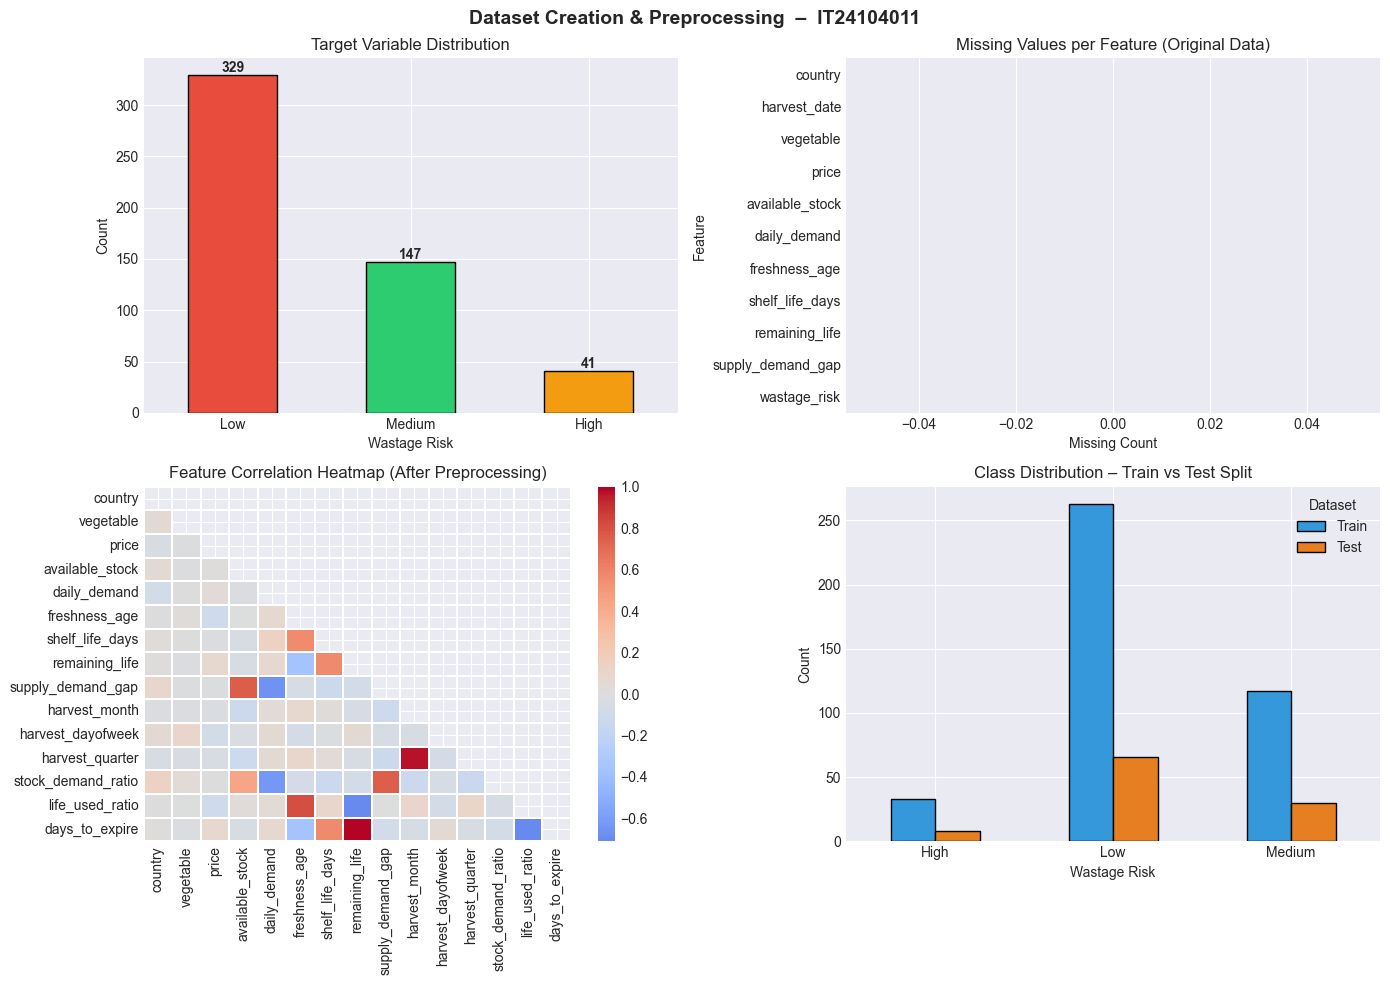

✅ Saved: preprocessing_summary.png
  PREPROCESSING COMPLETE – SUMMARY
  Total features after preprocessing : 15
  Training samples                   : 413
  Testing  samples                   : 104
  Target classes                     : ['High', 'Low', 'Medium']
  Missing values remaining           : 0
  Scaling applied                    : StandardScaler

  ✅ X_train, X_test, y_train, y_test are ready
     for the ML model training module.



In [18]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

DATASET_PATH = 'D:/Final project/vegetable_wastage_dataset_1000_rows (1).csv'

df      = pd.read_csv(DATASET_PATH)   # working copy
df_orig = pd.read_csv(DATASET_PATH)   # clean backup for visualizations

print("=" * 50)
print("✅ Dataset loaded successfully")
print("=" * 50)

# ============================================================
# NEW STEP: Filter for specific vegetables
# ============================================================

desired_vegetables = ['Onion', 'Brinjal', 'Potato', 'Tomato', 'Beans']

initial_rows = df.shape[0]
df      = df[df['vegetable'].isin(desired_vegetables)].copy()
df_orig = df_orig[df_orig['vegetable'].isin(desired_vegetables)].copy()

rows_after_filter = df.shape[0]

print("=" * 50)
print(f"✅ Filtered dataset for {len(desired_vegetables)} specific vegetables")
print(f"   Vegetables included: {', '.join(desired_vegetables)}")
print(f"   Rows before filtering: {initial_rows}")
print(f"   Rows after filtering : {rows_after_filter}")
print("=" * 50)

# ============================================================
# CELL 3: STEP 1 – Dataset Overview
# ============================================================

print("=" * 50)
print("STEP 1: DATASET OVERVIEW")
print("=" * 50)

print(f"Shape   : {df.shape}")
print(f"\nColumns : {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

# ============================================================
# CELL 4: STEP 2 – Data Inspection
# ============================================================

print("=" * 50)
print("STEP 2: DATA INSPECTION")
print("=" * 50)

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values per Column:")
print(df.isnull().sum())
print(f"Total missing values : {df.isnull().sum().sum()}")
print(f"\nDuplicate Rows       : {df.duplicated().sum()}")

print("\nTarget Variable Distribution:")
print(df['wastage_risk'].value_counts())

print("\nTarget Variable (%):")
print(df['wastage_risk'].value_counts(normalize=True)
        .mul(100).round(2).astype(str) + '%')

# ============================================================
# CELL 5: STEP 3 – Handling Missing Values
# ============================================================

print("=" * 50)
print("STEP 3: HANDLING MISSING VALUES")
print("=" * 50)

# Fill numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Filled '{col}' with median.")

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  Filled '{col}' with mode.")

print(f"\n✅ Missing values after handling: {df.isnull().sum().sum()}")

# ============================================================
# CELL 6: STEP 4 – Removing Duplicates
# ============================================================

print("=" * 50)
print("STEP 4: REMOVING DUPLICATES")
print("=" * 50)

before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Removed     : {before - after} duplicate(s)")
print("✅ Done")

# ============================================================
# CELL 7: STEP 5 – Date Feature Extraction
# ============================================================

print("=" * 50)
print("STEP 5: DATE FEATURE EXTRACTION")
print("=" * 50)

df['harvest_date']      = pd.to_datetime(df['harvest_date'])
df['harvest_month']     = df['harvest_date'].dt.month
df['harvest_dayofweek'] = df['harvest_date'].dt.dayofweek
df['harvest_quarter']   = df['harvest_date'].dt.quarter
df.drop(columns=['harvest_date'], inplace=True)

print("✅ Extracted : harvest_month, harvest_dayofweek, harvest_quarter")
print("✅ Dropped   : original 'harvest_date' column")

# ============================================================
# CELL 8: STEP 6 – Encoding Categorical Variables
# ============================================================

print("=" * 50)
print("STEP 6: ENCODING CATEGORICAL VARIABLES")
print("=" * 50)

le_country   = LabelEncoder()
le_vegetable = LabelEncoder()
le_target    = LabelEncoder()

df['country']          = le_country.fit_transform(df['country'])
df['vegetable']        = le_vegetable.fit_transform(df['vegetable'])
df['wastage_risk_enc'] = le_target.fit_transform(df['wastage_risk'])

print("Country classes   :", list(le_country.classes_))
print("Vegetable classes :", list(le_vegetable.classes_))
print("Target encoding   :", dict(zip(le_target.classes_,
                                       le_target.transform(le_target.classes_))))
print("✅ Encoding complete")

# ============================================================
# CELL 9: STEP 7 – Feature Engineering
# ============================================================

print("=" * 50)
print("STEP 7: FEATURE ENGINEERING")
print("=" * 50)

df['stock_demand_ratio'] = df['available_stock'] / (df['daily_demand'] + 1)
df['life_used_ratio']    = df['freshness_age']   / (df['shelf_life_days'] + 1)
df['days_to_expire']     = df['shelf_life_days'] - df['freshness_age']

print("✅ New features created:")
print("   stock_demand_ratio – ratio of available stock to daily demand")
print("   life_used_ratio    – proportion of shelf life already consumed")
print("   days_to_expire     – remaining days before expiry")

# ============================================================
# CELL 10: STEP 8 – Feature & Target Split
# ============================================================

print("=" * 50)
print("STEP 8: FEATURE & TARGET SPLIT")
print("=" * 50)

X = df.drop(columns=['wastage_risk', 'wastage_risk_enc'])
y = df['wastage_risk_enc']

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Features used        : {list(X.columns)}")

# ============================================================
# CELL 11: STEP 9 – Train / Test Split (80% / 20%)
# ============================================================

print("=" * 50)
print("STEP 9: TRAIN / TEST SPLIT (80% / 20%)")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class proportions in both sets
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"\nClass distribution – Train:\n{y_train.value_counts()}")
print(f"\nClass distribution – Test:\n{y_test.value_counts()}")

# ============================================================
# CELL 12: STEP 10 – Feature Scaling (StandardScaler)
# ============================================================

print("=" * 50)
print("STEP 10: FEATURE SCALING (StandardScaler)")
print("=" * 50)

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print("✅ Scaling applied: mean=0, std=1 for every feature")
print("\nSample scaled training rows:")
print(X_train.head(3))

# ============================================================
# CELL 13: STEP 11 – Preprocessing Visualizations
# ============================================================

print("=" * 50)
print("STEP 11: PREPROCESSING VISUALIZATIONS")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset Creation & Preprocessing  –  IT24104011",
             fontsize=14, fontweight='bold')

# ── Plot 1: Target class distribution ───────────────────────
ax     = axes[0, 0]
colors = ['#e74c3c', '#2ecc71', '#f39c12']
df_orig['wastage_risk'].value_counts().plot(
    kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title("Target Variable Distribution")
ax.set_xlabel("Wastage Risk")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

# ── Plot 2: Missing values per feature ──────────────────────
ax           = axes[0, 1]
missing_data = df_orig.isnull().sum().reset_index()
missing_data.columns = ['Feature', 'Missing Count']
sns.barplot(data=missing_data, x='Missing Count',
            y='Feature', ax=ax, color='steelblue')
ax.set_title("Missing Values per Feature (Original Data)")
ax.set_xlabel("Missing Count")

# ── Plot 3: Feature correlation heatmap ─────────────────────
ax   = axes[1, 0]
corr = X_train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, cmap='coolwarm', annot=False,
            linewidths=0.3, mask=mask, center=0)
ax.set_title("Feature Correlation Heatmap (After Preprocessing)")

# ── Plot 4: Class balance Train vs Test ─────────────────────
ax       = axes[1, 1]
split_df = pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Test' : y_test.value_counts().sort_index()
})
split_df.index = [le_target.classes_[i] for i in split_df.index]
split_df.plot(kind='bar', ax=ax,
              color=['#3498db', '#e67e22'], edgecolor='black')
ax.set_title("Class Distribution – Train vs Test Split")
ax.set_xlabel("Wastage Risk")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Dataset')

plt.tight_layout()
plt.savefig("preprocessing_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: preprocessing_summary.png")

# ============================================================
# CELL 14: PREPROCESSING COMPLETE – SUMMARY
# ============================================================

print("=" * 55)
print("  PREPROCESSING COMPLETE – SUMMARY")
print("=" * 55)
print(f"  Total features after preprocessing : {X_train.shape[1]}")
print(f"  Training samples                   : {X_train.shape[0]}")
print(f"  Testing  samples                   : {X_test.shape[0]}")
print(f"  Target classes                     : {list(le_target.classes_)}")
print(f"  Missing values remaining           : 0")
print(f"  Scaling applied                    : StandardScaler")
print("\n  ✅ X_train, X_test, y_train, y_test are ready")
print("     for the ML model training module.\n")

In [17]:
print(type(model))
print(type(scaler))
print(type(le_vegetable))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
<class 'sklearn.preprocessing._data.StandardScaler'>
<class 'sklearn.preprocessing._label.LabelEncoder'>
